# Multimodal Biomarker Feature Importance Analysis for rTMS in Alzheimer's Disease

## Phase 1: Binary Classification Analysis

This notebook implements a comprehensive machine learning pipeline to identify predictive biomarkers for treatment response in Alzheimer's Disease patients undergoing repetitive Transcranial Magnetic Stimulation (rTMS).

### Objectives
- **Data Preparation**: Load and preprocess clinical and neuroimaging data
- **Feature Analysis**: Statistical analysis of feature-target relationships
- **Model Training**: Train and evaluate L1 Logistic Regression, Random Forest, and XGBoost classifiers
- **Interpretation**: Extract feature importance using coefficients, permutation importance, and SHAP values

### Target Variable
- **Declined (1)**: Patients who declined after treatment (positive class)
- **Improved (0)**: Patients who improved after treatment (negative class)

---


## 1. Environment Setup

Check system resources and Python environment configuration.


In [1]:
import psutil, platform, os

print("Python:", platform.python_version())
print("OS:", platform.system(), platform.release())
print("CPU count (logical):", psutil.cpu_count())
print("Total RAM (GB):", round(psutil.virtual_memory().total / 1e9, 2))

# Disk space (works on both Windows and Linux)
disk = psutil.disk_usage(os.getcwd())
print(f"Disk free (GB): {round(disk.free / 1e9, 2)}")



Python: 3.13.5
OS: Windows 11
CPU count (logical): 12
Total RAM (GB): 17.09
Disk free (GB): 150.8


## 2. Data Loading

Mount Google Drive and set up the project directory.


In [7]:
import os
import platform

# ============================================================
# CONFIGURATION: Set your data path here
# ============================================================
# Option 1: Google Drive Desktop App (syncs to local folder)
#   - Windows default: "G:/My Drive/..." or "C:/Users/<username>/Google Drive/..."
#   - Find your path in File Explorer where Google Drive syncs
#
# Option 2: Download data locally to this project folder
# ============================================================

if platform.system() == "Windows":
    # Local path to Google Drive folder
    PROJECT_DIR = r"D:\My Drive\Dr_Moussavi"
else:
    # Colab / Linux path
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_DIR = "/content/drive/MyDrive/Dr_Moussavi"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"\nFiles in project directory:")
for f in os.listdir(".")[:20]:  # Show first 20 files
    print(f"  {f}")


Working directory: D:\My Drive\Dr_Moussavi

Files in project directory:
  Studies Papers
  Dataset
  Notes
  docker
  Presentation
  Project
  grouped_stats_full.csv
  model_params_generic_soft
  plots_l1_metrics_main_vs_diag_l1.png
  plots_l1_l1_coeffs_odds_l1.png
  plots_l1_probability_distribution_l1_diag.png
  plots_l1_confusion_matrices_l1.png
  plots_rf_confusion_matrices_rf.png
  plots_l1_shap_force_sample0_l1.html
  plots_l1_shap_dependence_l1.png
  plots_l1_shap_summary_l1.png
  plots_l1_perm_importance_l1.png
  plots_l1_probability_distribution_l1.png
  plots_l1_l1_vs_diag_coeffs_l1.png
  plots_xgb_metrics_main_vs_diag_xgb.png


### 2.1 Verify Data Path


In [8]:
print(os.path.abspath('../Dr_Moussavi/Dataset/Combined_v6_Updated.xlsx'))
print(os.path.exists('../Dr_Moussavi/Dataset/Combined_v6_Updated.xlsx'))


D:\My Drive\Dr_Moussavi\Dataset\Combined_v6_Updated.xlsx
True


## 3. Data Preparation

### 3.1 Load and Filter Dataset

Load the Excel dataset and create filtered dataframes for different analysis groups:
- **Active Group (R2/R4)**: Patients receiving active rTMS treatment
- **Sham Group (S4)**: Patients receiving sham treatment
- **Combined (Active + Sham)**: All patients

For each group, we create:
- Binary classification targets (threshold 0 and threshold 1)
- Multiclass classification targets


In [9]:
import pandas as pd
import numpy as np
import io
import contextlib
import sys

class TeeStdout:
    def __init__(self, *streams):
        self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data)
    def flush(self):
        for s in self.streams:
            s.flush()

# -------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------
df = pd.read_excel('../Dr_Moussavi/Dataset/Combined_v6_Updated.xlsx')
# print(df.shape)
# print(df['w5_change_binary_one_threshold'].value_counts(dropna=False))

# -------------------------------------------------------------------
# 2. DATA CLEANING AND PREPARATION PIPELINE Active
# -------------------------------------------------------------------

print("\nActive\n" + "="*50)
# -------------------------------------------------------------------
# Active
# Binary class target 0
features_to_keep_binary_0= [
    'Age at Enrollment',
    'Gender',
    'CDR',
    'MoCA',
    'CSDD',
    'HIS_2_Threshold',
    'Norm_V_R_DLPFC_GM',
    'Norm_V_L_DLPFC_GM',
    'Norm_V_R_DLPFC_WM',
    'Norm_V_L_DLPFC_WM',
    'GM_Asymmetry_Index',
    'WM_Asymmetry_Index',
    'Norm_WMH',
    'Norm_WMH_FL',
    'Norm_WMH_R_DLPFC_mm',
    'Norm_WMH_L_DLPFC_mm',
    'w5_change_binary_zero_threshold'
]

df_binary_0_a = df[
    df['w5_change_binary_zero_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['R2', 'R4'])
][features_to_keep_binary_0].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active Binary class target 0:")
print(df_binary_0_a.shape)
print(df_binary_0_a['w5_change_binary_zero_threshold'].value_counts(dropna=False))
# df_binary_0_a

# -------------------------------------------------------------------
# Binary class target 1
features_to_keep_binary_1 = [
    'Age at Enrollment',
    'Gender',
    'CDR',
    'MoCA',
    'CSDD',
    'HIS_2_Threshold',
    'Norm_V_R_DLPFC_GM',
    'Norm_V_L_DLPFC_GM',
    'Norm_V_R_DLPFC_WM',
    'Norm_V_L_DLPFC_WM',
    'GM_Asymmetry_Index',
    'WM_Asymmetry_Index',
    'Norm_WMH',
    'Norm_WMH_FL',
    'Norm_WMH_R_DLPFC_mm',
    'Norm_WMH_L_DLPFC_mm',
    'w5_change_binary_one_threshold'
]

df_binary_1_a = df[
    df['w5_change_binary_one_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['R2', 'R4'])
][features_to_keep_binary_1].copy().reset_index(drop=True)


print("\n" + "-"*50)
print("Active Binary class target 1:")
print(df_binary_1_a.shape)
print(df_binary_1_a['w5_change_binary_one_threshold'].value_counts(dropna=False))
# df_binary_1_a

# -------------------------------------------------------------------
# Multiclass target
features_to_keep_multi = [
    'Age at Enrollment',
    'Gender',
    'CDR',
    'MoCA',
    'CSDD',
    'HIS_2_Threshold',
    'Norm_V_R_DLPFC_GM',
    'Norm_V_L_DLPFC_GM',
    'Norm_V_R_DLPFC_WM',
    'Norm_V_L_DLPFC_WM',
    'GM_Asymmetry_Index',
    'WM_Asymmetry_Index',
    'Norm_WMH',
    'Norm_WMH_FL',
    'Norm_WMH_R_DLPFC_mm',
    'Norm_WMH_L_DLPFC_mm',
    'w5_change_multiclass_one_threshold'
]

df_multiclass_1_a = df[
    df['w5_change_multiclass_one_threshold'].isin(['Declined', 'Improved', 'No Change']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['R2', 'R4'])
][features_to_keep_multi].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active Multi class target 1:")
print(df_multiclass_1_a.shape)
print(df_multiclass_1_a['w5_change_multiclass_one_threshold'].value_counts(dropna=False))
# df_multiclass_1_a

print("\nSham\n" + "="*50)
# -------------------------------------------------------------------
# Sham

# -------------------------------------------------------------------
# Binary class target 0
df_binary_0_s = df[
    df['w5_change_binary_zero_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4'])
][features_to_keep_binary_0].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Sham Binary class target 0:")
print(df_binary_0_s.shape)
print(df_binary_0_s['w5_change_binary_zero_threshold'].value_counts(dropna=False))
# df_binary_0_s

# -------------------------------------------------------------------
# Binary class target 1
df_binary_1_s = df[
    df['w5_change_binary_one_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4'])
][features_to_keep_binary_1].copy().reset_index(drop=True)


print("\n" + "-"*50)
print("Sham Binary class target 1:")
print(df_binary_1_s.shape)
print(df_binary_1_s['w5_change_binary_one_threshold'].value_counts(dropna=False))
# df_binary_1_s

# -------------------------------------------------------------------
# Multiclass target
df_multiclass_1_s = df[
    df['w5_change_multiclass_one_threshold'].isin(['Declined', 'Improved', 'No Change']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4'])
][features_to_keep_multi].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Sham Multi class target 1:")
print(df_multiclass_1_s.shape)
print(df_multiclass_1_s['w5_change_multiclass_one_threshold'].value_counts(dropna=False))
# df_multiclass_1_s

print("\nActive + Sham\n" + "="*50)
# -------------------------------------------------------------------
# Active + Sham

# -------------------------------------------------------------------
# Binary class target 0
df_binary_0_as = df[
    df['w5_change_binary_zero_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4', 'R2', 'R4'])
][features_to_keep_binary_0].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active + Sham Binary class target 0:")
print(df_binary_0_as.shape)
print(df_binary_0_as['w5_change_binary_zero_threshold'].value_counts(dropna=False))
# df_binary_0_as

# -------------------------------------------------------------------
# Binary class target 1
df_binary_1_as = df[
    df['w5_change_binary_one_threshold'].isin(['Declined', 'Improved']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4', 'R2', 'R4'])
][features_to_keep_binary_1].copy().reset_index(drop=True)


print("\n" + "-"*50)
print("Active + Sham Binary class target 1:")
print(df_binary_1_as.shape)
print(df_binary_1_as['w5_change_binary_one_threshold'].value_counts(dropna=False))
# df_binary_1_as

# -------------------------------------------------------------------
# Multiclass target
df_multiclass_1_as = df[
    df['w5_change_multiclass_one_threshold'].isin(['Declined', 'Improved', 'No Change']) &
    df['TIV'].notna() &
    df['Participant.Treatment.Group'].isin(['S4', 'R2', 'R4'])
][features_to_keep_multi].copy().reset_index(drop=True)

print("\n" + "-"*50)
print("Active + Sham Multi class target 1:")
print(df_multiclass_1_as.shape)
print(df_multiclass_1_as['w5_change_multiclass_one_threshold'].value_counts(dropna=False))
# df_multiclass_1_as


Active

--------------------------------------------------
Active Binary class target 0:
(74, 17)
w5_change_binary_zero_threshold
Improved    52
Declined    22
Name: count, dtype: int64

--------------------------------------------------
Active Binary class target 1:
(58, 17)
w5_change_binary_one_threshold
Improved    46
Declined    12
Name: count, dtype: int64

--------------------------------------------------
Active Multi class target 1:
(74, 17)
w5_change_multiclass_one_threshold
Improved     46
No Change    16
Declined     12
Name: count, dtype: int64

Sham

--------------------------------------------------
Sham Binary class target 0:
(35, 17)
w5_change_binary_zero_threshold
Improved    20
Declined    15
Name: count, dtype: int64

--------------------------------------------------
Sham Binary class target 1:
(28, 17)
w5_change_binary_one_threshold
Improved    19
Declined     9
Name: count, dtype: int64

--------------------------------------------------
Sham Multi class target 1

### 3.2 Display Settings


In [10]:
pd.set_option("display.max_rows", None)        # or a large number like 500
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.width", 0)              # auto-detect width
pd.set_option("display.max_colwidth", None)    # don't truncate column content

### 3.3 Preview Data

Preview the Active group binary threshold 1 dataset.


In [11]:
df_binary_1_a.head()

,Age at Enrollment,Gender,CDR,MoCA,CSDD,HIS_2_Threshold,Norm_V_R_DLPFC_GM,Norm_V_L_DLPFC_GM,Norm_V_R_DLPFC_WM,Norm_V_L_DLPFC_WM,GM_Asymmetry_Index,WM_Asymmetry_Index,Norm_WMH,Norm_WMH_FL,Norm_WMH_R_DLPFC_mm,Norm_WMH_L_DLPFC_mm,w5_change_binary_one_threshold
0,72,Male,2.0,18,6,Low,0.000448,0.000590,0.000330,0.000369,13.614104,5.633923,0.002573,0.001169,0.000000e+00,2.033586e-07,Improved
1,73,Male,1.0,14,17,High,0.000527,0.000497,0.000309,0.000340,2.953389,4.818165,0.012035,0.005307,8.251911e-06,6.787590e-07,Improved
2,82,Male,1.0,22,8,High,0.000386,0.000557,0.000354,0.000228,18.101388,21.619925,0.002469,0.000849,0.000000e+00,1.690165e-08,Improved
3,79,Male,1.0,13,2,High,0.000357,0.000436,0.000478,0.000368,10.011159,13.016158,0.014435,0.005184,5.188485e-06,9.031499e-08,Improved
4,63,Female,1.0,16,4,Low,0.000401,0.000446,0.000351,0.000308,5.324107,6.537135,0.005075,0.002065,3.259019e-07,8.283270e-07,Improved


### 3.4 Encode Target and Binary Features

Encode categorical variables for modeling:
- **Target**: Declined → 1 (positive class), Improved → 0 (negative class)
- **Gender**: Male → 1, Female → 0
- **HIS_2_Threshold**: High → 1, Low → 0


In [12]:
# -------------------------------------------------------------------
# 1. DATA PREPARATION (Using loaded df_binary_1_a)
# -------------------------------------------------------------------
print("--- Phase 1 Analysis: Active Group (R2/R4), Extreme Threshold ---")

# Create a working copy to avoid SettingWithCopy warnings
df_analysis_binary_1_a = df_binary_1_a.copy()

print(f"Total Samples: {len(df_analysis_binary_1_a)}")
print("Original Target Counts:")
print(df_analysis_binary_1_a['w5_change_binary_one_threshold'].value_counts())

# --- ENCODING ---
# 1. Target: Declined (Positive Class) = 1, Improved (Negative Class) = 0
target_map = {'Declined': 1, 'Improved': 0}
df_analysis_binary_1_a['w5_change_binary_one_threshold'] = df_analysis_binary_1_a['w5_change_binary_one_threshold'].map(target_map)

# 2. Binary Features Encoding
# Check actual values in your DF to ensure mapping is correct
# Assuming Gender is 'Male'/'Female' and HIS is 'High'/'Low'
gender_map = {'Male': 1, 'Female': 0}
his_map = {'High': 1, 'Low': 0}

# Safe mapping (handles potential variations if needed, but assumes standard)
if 'Gender' in df_analysis_binary_1_a.columns:
    df_analysis_binary_1_a['Gender'] = df_analysis_binary_1_a['Gender'].map(gender_map)
if 'HIS_2_Threshold' in df_analysis_binary_1_a.columns:
    df_analysis_binary_1_a['HIS_2_Threshold'] = df_analysis_binary_1_a['HIS_2_Threshold'].map(his_map)


--- Phase 1 Analysis: Active Group (R2/R4), Extreme Threshold ---
Total Samples: 58
Original Target Counts:
w5_change_binary_one_threshold
Improved    46
Declined    12
Name: count, dtype: int64


### 3.5 Verify Encoded Data


In [13]:
df_analysis_binary_1_a.head(3)

,Age at Enrollment,Gender,CDR,MoCA,CSDD,HIS_2_Threshold,Norm_V_R_DLPFC_GM,Norm_V_L_DLPFC_GM,Norm_V_R_DLPFC_WM,Norm_V_L_DLPFC_WM,GM_Asymmetry_Index,WM_Asymmetry_Index,Norm_WMH,Norm_WMH_FL,Norm_WMH_R_DLPFC_mm,Norm_WMH_L_DLPFC_mm,w5_change_binary_one_threshold
0,72,1,2.0,18,6,0,0.000448,0.000590,0.000330,0.000369,13.614104,5.633923,0.002573,0.001169,0.000000,2.033586e-07,0
1,73,1,1.0,14,17,1,0.000527,0.000497,0.000309,0.000340,2.953389,4.818165,0.012035,0.005307,0.000008,6.787590e-07,0
2,82,1,1.0,22,8,1,0.000386,0.000557,0.000354,0.000228,18.101388,21.619925,0.002469,0.000849,0.000000,1.690165e-08,0


---

## 4. Exploratory Data Analysis

### 4.1 Descriptive Statistics by Target Class

Summary statistics for each feature grouped by outcome (Improved vs Declined).


In [14]:
# Use groupby and describe to summarize numeric features for each group:
grouped_stats = df_analysis_binary_1_a.groupby("w5_change_binary_one_threshold").describe().T
grouped_stats.to_csv("grouped_stats_full.csv")
print(grouped_stats)


w5_change_binary_one_threshold             0             1
Age at Enrollment   count       4.600000e+01  1.200000e+01
                    mean        7.267391e+01  7.500000e+01
                    std         8.080303e+00  6.755469e+00
                    min         5.500000e+01  6.600000e+01
                    25%         6.900000e+01  6.925000e+01
                    50%         7.400000e+01  7.600000e+01
                    75%         7.800000e+01  7.875000e+01
                    max         8.900000e+01  8.600000e+01
Gender              count       4.600000e+01  1.200000e+01
                    mean        5.652174e-01  5.000000e-01
                    std         5.012063e-01  5.222330e-01
                    min         0.000000e+00  0.000000e+00
                    25%         0.000000e+00  0.000000e+00
                    50%         1.000000e+00  5.000000e-01
                    75%         1.000000e+00  1.000000e+00
                    max         1.000000e+00  1.000000e+

### 4.2 Train/Test Split

Create stratified train/test split to preserve class distribution.


In [15]:
from sklearn.model_selection import train_test_split
# 3. Define X and y
# Drop the target columns
cols_to_drop = ['w5_change_binary_one_threshold']
# Only drop if they exist
X = df_analysis_binary_1_a.drop(columns=[c for c in cols_to_drop if c in df_analysis_binary_1_a.columns])
y = df_analysis_binary_1_a['w5_change_binary_one_threshold']

# Handle any remaining NaNs (e.g. if mapping failed or missing values existed)
if X.isnull().values.any():
    print("Warning: NaN values found in features. Imputing with median/mode...")
    X = X.fillna(X.median(numeric_only=True))
    # For binary columns that might be NaN after mapping
    for col in ['Gender', 'HIS_2_Threshold']:
        if col in X.columns:
             X[col] = X[col].fillna(X[col].mode()[0])

# 4. Train/Test Split
# Using 20% split. With 12 positives, this puts ~2-3 in test set.
# Stratify is crucial for small, imbalanced data.
RND = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RND
)

print("-" * 30)
print(f"Train Shape: {X_train.shape}, Positives (Decliners): {y_train.sum()}, Negatives (Improvers): {len(y_train) - y_train.sum()}")
print(f"Test Shape: {X_test.shape}, Positives (Decliners): {y_test.sum()}, Negatives (Improvers): {len(y_test) - y_test.sum()}")
print("-" * 30)

------------------------------
Train Shape: (46, 16), Positives (Decliners): 10, Negatives (Improvers): 36
Test Shape: (12, 16), Positives (Decliners): 2, Negatives (Improvers): 10
------------------------------


### 4.3 Gender Distribution by Outcome


In [16]:
gender_counts = df_analysis_binary_1_a.groupby(['w5_change_binary_one_threshold', 'Gender']).size().unstack(fill_value=0)
display(gender_counts)

Gender,0,1
w5_change_binary_one_threshold,,
0,20,26
1,6,6


---

## 5. Statistical Feature Analysis

Univariate statistical analysis to assess feature-target relationships:
- **Pearson Correlation**: Linear relationship strength
- **Spearman Correlation**: Monotonic relationship strength  
- **Phi Coefficient**: Association between binary variables
- **Univariate ROC-AUC**: Discriminative power of individual features
- **Mutual Information**: Non-linear dependency measure


In [17]:
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
# --------------------- STATISTICAL ANALYSES ---------------------

# 1) Pearson (rank by absolute value, print signed)
print("Calculating Pearson...")
pearson = X.corrwith(y, method="pearson")
pearson_abs_ranked = pearson.loc[pearson.abs().sort_values(ascending=False).index]

# 2) Spearman (rank by absolute value, print signed)
print("Calculating Spearman...")
spearman = X.corrwith(y, method="spearman")
spearman_abs_ranked = spearman.loc[spearman.abs().sort_values(ascending=False).index]

# 3) Phi coefficient for Gender & HIS vs target (Pearson on two binaries)
print("Calculating Phi...")
phi_features = {}
for binary_col in ["Gender", "HIS_2_Threshold"]:
    if binary_col in X.columns:
        # Pearson corr on two binary vars IS the Phi coefficient
        phi_val = X[binary_col].corr(y, method="pearson")
        phi_features[binary_col] = phi_val

phi_series = pd.Series(phi_features)
phi_abs_ranked = phi_series.loc[phi_series.abs().sort_values(ascending=False).index]

# 4) Univariate ROC AUC and signed AUC per feature
print("Calculating Univariate AUC...")
auc = {}
signed_auc = {}
for col in X.columns:
    xi = X[col]
    yi = y

    # Skip constants or single-class slices (cannot calc AUC)
    if xi.nunique() <= 1 or yi.nunique() <= 1:
        auc[col] = np.nan
        signed_auc[col] = np.nan
        continue
    try:
        a = roc_auc_score(yi, xi)
        auc[col] = a
        signed_auc[col] = 2 * (a - 0.5)  # [-1, 1], sign indicates direction
    except Exception as e:
        print(f"Could not calc AUC for {col}: {e}")
        auc[col] = np.nan
        signed_auc[col] = np.nan

auc = pd.Series(auc)
signed_auc = pd.Series(signed_auc)

# Rank AUC by |AUC - 0.5| (print raw AUC in that order)
auc_absdev_rank_idx = (auc - 0.5).abs().sort_values(ascending=False).index
auc_absdev_ranked = auc.loc[auc_absdev_rank_idx]

# Rank signed AUC by absolute value (print signed)
signed_auc_abs_ranked = signed_auc.loc[signed_auc.abs().sort_values(ascending=False).index]

# 5) Mutual Information (non-linear dependency) (rank by absolute value, print value)
print("Calculating Mutual Information...")
# Identify discrete features for MI (Gender and HIS_2_Threshold are binary/discrete)
discrete_cols = ["Gender", "HIS_2_Threshold"]
discrete_mask = [col in discrete_cols for col in X.columns]

mi_vals = mutual_info_classif(X.values, y.values, discrete_features=discrete_mask, random_state=42)
mi = pd.Series(mi_vals, index=X.columns)
mi_abs_ranked = mi.sort_values(ascending=False)


# --------------------- PRINT RESULTS ---------------------
print("\n" + "="*60)
print("STATISTICAL ANALYSIS RESULTS (Active Group, Declined=1)")
print("="*60)

print("\n--- [PEARSON] (Linear Correlation) ---")
print("Ranked by Magnitude (|r|), showing signed value:")
print(pearson_abs_ranked.to_string())

print("\n--- [SPEARMAN] (Monotonic Correlation) ---")
print("Ranked by Magnitude (|rho|), showing signed value:")
print(spearman_abs_ranked.to_string())

print("\n--- [PHI COEFFICIENT] (Binary vs Binary) ---")
print("Ranked by Magnitude (|phi|):")
print(phi_abs_ranked.to_string())

print("\n--- [Univariate ROC AUC] (Discriminative Power) ---")
print("Ranked by Separation Power (|AUC - 0.5|), showing raw AUC:")
print(auc_absdev_ranked.to_string())

print("\n--- [Signed AUC] (Directional Discrimination) ---")
print("Ranked by Magnitude (|Signed AUC|), showing signed value:")
print(signed_auc_abs_ranked.to_string())

print("\n--- [MUTUAL INFORMATION] (Non-Linear Dependency) ---")
print("Ranked by Information Gain (Higher is better):")
print(mi_abs_ranked.to_string())
print("="*60)

Calculating Pearson...
Calculating Spearman...
Calculating Phi...
Calculating Univariate AUC...
Calculating Mutual Information...

STATISTICAL ANALYSIS RESULTS (Active Group, Declined=1)

--- [PEARSON] (Linear Correlation) ---
Ranked by Magnitude (|r|), showing signed value:
GM_Asymmetry_Index    -0.290904
HIS_2_Threshold        0.175820
Norm_V_R_DLPFC_GM      0.156287
Norm_V_R_DLPFC_WM      0.124682
Age at Enrollment      0.121442
Norm_V_L_DLPFC_WM      0.096783
CDR                    0.083162
Norm_WMH_R_DLPFC_mm   -0.073946
Norm_WMH               0.070450
WM_Asymmetry_Index     0.061167
Gender                -0.053122
Norm_WMH_L_DLPFC_mm   -0.046042
Norm_V_L_DLPFC_GM      0.042655
CSDD                   0.034988
Norm_WMH_FL            0.030957
MoCA                   0.002868

--- [SPEARMAN] (Monotonic Correlation) ---
Ranked by Magnitude (|rho|), showing signed value:
GM_Asymmetry_Index    -0.300013
Norm_WMH               0.277130
Norm_WMH_FL            0.223738
Norm_WMH_R_DLPFC_mm  

---

## 5.1 ANOVA Feature Selection

Analysis of Variance (ANOVA) F-test to identify features with significant differences between outcome groups. Features with low F-scores (high p-values) may be redundant and candidates for removal.

**Interpretation:**
- **High F-score**: Feature shows significant variance between groups → potentially predictive
- **Low F-score / High p-value**: Feature does not discriminate between groups → candidate for removal


In [18]:
from sklearn.feature_selection import f_classif, SelectKBest
from scipy import stats

# ============================================================
# ANOVA F-test for Feature Selection
# ============================================================

# Get feature matrix and target (using the encoded data)
X_anova = df_analysis_binary_1_a.drop(columns=['w5_change_binary_one_threshold'])
y_anova = df_analysis_binary_1_a['w5_change_binary_one_threshold']

# Compute ANOVA F-scores and p-values
f_scores, p_values = f_classif(X_anova, y_anova)

# Create results DataFrame
anova_results = pd.DataFrame({
    'Feature': X_anova.columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

# Add significance indicator
anova_results['Significant'] = anova_results['P_Value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)

print("=" * 70)
print("ANOVA F-TEST RESULTS")
print("=" * 70)
print("\nFeatures ranked by F-score (higher = more discriminative):\n")
print(anova_results.to_string(index=False))

# Identify potentially redundant features (p > 0.1)
redundant_features = anova_results[anova_results['P_Value'] > 0.1]['Feature'].tolist()
significant_features = anova_results[anova_results['P_Value'] < 0.05]['Feature'].tolist()

print("\n" + "-" * 70)
print(f"\n✓ Significant features (p < 0.05): {significant_features if significant_features else 'None'}")
print(f"\n⚠ Potentially redundant features (p > 0.1): {redundant_features if redundant_features else 'None'}")
print("\n" + "=" * 70)


ANOVA F-TEST RESULTS

Features ranked by F-score (higher = more discriminative):

            Feature  F_Score  P_Value Significant
 GM_Asymmetry_Index 5.177123 0.026734           *
    HIS_2_Threshold 1.786322 0.186780            
  Norm_V_R_DLPFC_GM 1.402085 0.241376            
  Norm_V_R_DLPFC_WM 0.884301 0.351065            
  Age at Enrollment 0.838260 0.363821            
  Norm_V_L_DLPFC_WM 0.529509 0.469845            
                CDR 0.389988 0.534842            
Norm_WMH_R_DLPFC_mm 0.307888 0.581189            
           Norm_WMH 0.279327 0.599231            
 WM_Asymmetry_Index 0.210303 0.648305            
             Gender 0.158474 0.692079            
Norm_WMH_L_DLPFC_mm 0.118963 0.731454            
  Norm_V_L_DLPFC_GM 0.102073 0.750545            
               CSDD 0.068636 0.794294            
        Norm_WMH_FL 0.053718 0.817561            
               MoCA 0.000460 0.982956            

-------------------------------------------------------------------

---

## 6. Machine Learning Modeling Framework

### 6.1 Framework Definition

This section defines a flexible modeling framework supporting:
- **L1 Logistic Regression**: Sparse feature selection via L1 regularization
- **Random Forest**: Ensemble of decision trees with bagging
- **XGBoost**: Gradient boosted decision trees

Key features:
- Nested cross-validation for unbiased performance estimation
- Grid search for hyperparameter tuning
- SMOTE support for handling class imbalance
- Diagnostic models for comparison
- Automatic artifact saving with versioning


In [ ]:
"""
Hyper-Flexible Modeling Framework for Active Binary-1 Dataset
=============================================================

Core features:
- Works with df_binary_1_a (Active R2/R4, binary-1 target).
- Target: w5_change_binary_one_threshold (Declined vs Improved).
  * Declined -> 1 (positive, "bad" outcome we want to catch).
  * Improved -> 0 (negative).
- Supports 3 models:
  * L1-regularized Logistic Regression
  * Random Forest
  * XGBoost

Fully soft-coded:
- Model factories accept:
  * base_kwargs: dict of estimator init kwargs
  * grid_overrides: dict to override / extend default param grids
- Diagnostic models accept:
  * diag_kwargs: dict of diagnostic estimator init kwargs
  * diag_threshold: float for decision threshold

Validation:
- Stratified train/test split with configurable test_size and seed.
- Nested or non-nested CV:
  * with arbitrary CV classes (StratifiedKFold, RepeatedStratifiedKFold, etc.)
  * all CV parameters set in main().

Outputs:
- Detailed logs (CV, tuning, test metrics).
- Feature effects (coefficients + odds ratios for L1, importances for RF/XGB).
- Diagnostic models with metrics and feature effects.
- All artifacts saved under ROOT_MODEL_DIR/<model_tag>/.
"""

import os
import joblib
import numpy as np
import pandas as pd

from typing import Dict, Tuple, Any, Optional, Callable

from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, RepeatedStratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score, confusion_matrix
)

import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Replace sklearn Pipeline



# =============================================================================
# 1. PROJECT-WIDE CONSTANTS AND DATA LOADING
# =============================================================================

TARGET = "w5_change_binary_one_threshold"
EXPLICIT_BINARY = ["Gender", "HIS_2_Threshold"]
ROOT_MODEL_DIR = "model_params_generic_soft"


def load_project_dataframe() -> pd.DataFrame:
    """
    Load df_binary_1_a prepared in a separate script.

    Requirements for df_binary_1_a:
    - Active (R2+R4) only
    - Non-missing TIV
    - Target column w5_change_binary_one_threshold with values "Declined"/"Improved"
    - Only the selected features (clinical, structural, symmetry, vascular, Gender, HIS_2_Threshold)
    """
    print("\n[DATA] Loading project dataframe: df_binary_1_a")
    df = df_binary_1_a.copy()
    print(f"       Shape: {df.shape}")
    print("       Raw target value counts:")
    print(df[TARGET].value_counts(dropna=False))
    return df


# =============================================================================
# 2. ENCODING & FEATURE TYPE DETECTION
# =============================================================================

def encode_target_and_binary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encode target and explicit binary features to 0/1.

    Target:
        Declined -> 1  (positive class)
        Improved -> 0  (negative class)

    Predictors:
        Gender: Male -> 1, Female -> 0
        HIS_2_Threshold: High -> 1, Low -> 0
    """
    print("\n[ENCODE] Encoding target and binary predictors...")

    target_map = {"Declined": 1, "Improved": 0}
    df[TARGET] = df[TARGET].map(target_map)
    if df[TARGET].isna().any():
        raise ValueError("Unmapped values in TARGET after Declined/Improved mapping.")
    df[TARGET] = df[TARGET].astype(int)
    print("         TARGET mapped: Declined -> 1, Improved -> 0")
    print("         Target counts after mapping:")
    print(df[TARGET].value_counts())

    if "Gender" in df.columns:
        print("\n         Encoding Gender: Male->1, Female->0")
        gender_map = {"Male": 1, "Female": 0}
        df["Gender"] = df["Gender"].map(gender_map)
        if df["Gender"].isna().any():
            print("         WARNING: Some Gender values not mapped. Check raw data.")
        df["Gender"] = df["Gender"].astype(float)
        print("         Gender counts after mapping:")
        print(df["Gender"].value_counts(dropna=False))

    if "HIS_2_Threshold" in df.columns:
        print("\n         Encoding HIS_2_Threshold: High->1, Low->0")
        his_map = {"High": 1, "Low": 0}
        df["HIS_2_Threshold"] = df["HIS_2_Threshold"].map(his_map)
        if df["HIS_2_Threshold"].isna().any():
            print("         WARNING: Some HIS_2_Threshold values not mapped. Check raw data.")
        df["HIS_2_Threshold"] = df["HIS_2_Threshold"].astype(float)
        print("         HIS_2_Threshold counts after mapping:")
        print(df["HIS_2_Threshold"].value_counts(dropna=False))

    return df


def detect_feature_types(
    df: pd.DataFrame,
    target_col: str,
    explicit_binary: list
) -> Tuple[list, list]:
    """
    Detect numeric vs binary feature columns.

    binary_cols:
        - All in explicit_binary
        - All numeric columns with exactly 2 unique non-NA values
    numeric_cols:
        - Remaining numeric columns, excluding target and binary
    leftovers:
        - Any non-numeric, non-binary, non-target -> error
    """
    print("\n[FEATURE TYPES] Detecting numeric / binary / leftover columns...")
    binary_cols = []

    for c in df.columns:
        if c == target_col:
            continue
        if c in explicit_binary:
            binary_cols.append(c)
            continue
        if np.issubdtype(df[c].dtype, np.number) and df[c].nunique(dropna=True) == 2:
            if c not in binary_cols:
                binary_cols.append(c)

    numeric_cols = [
        c for c in df.columns
        if c not in binary_cols + [target_col]
        and np.issubdtype(df[c].dtype, np.number)
    ]

    leftovers = [
        c for c in df.columns
        if c not in numeric_cols + binary_cols + [target_col]
    ]

    print(f"               Binary columns:  {binary_cols}")
    print(f"               Numeric columns: {numeric_cols}")
    if leftovers:
        print(f"               Leftover columns: {leftovers}")
        raise ValueError(f"Columns need encoding before modeling: {leftovers}")
    else:
        print("               No leftover columns. All features numeric or binary.")
    return numeric_cols, binary_cols


# =============================================================================
# 3. PREPROCESSING & TRAIN/TEST SPLIT
# =============================================================================

def stratified_split(
    df: pd.DataFrame,
    numeric_cols: list,
    binary_cols: list,
    target_col: str,
    test_size: float,
    rnd: int
):
    """
    Perform a stratified train/test split.

    Returns:
        X_train, X_test, y_train, y_test
    """
    print("\n[SPLIT] Creating stratified train/test split...")
    X = df[numeric_cols + binary_cols].copy()
    y = df[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=rnd
    )

    print(f"        X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
    print("        Train target counts:")
    print(y_train.value_counts())
    print("        Test target counts:")
    print(y_test.value_counts())
    return X_train, X_test, y_train, y_test


def build_preprocessor(
    numeric_cols: list,
    binary_cols: list
) -> ColumnTransformer:
    """
    Build a ColumnTransformer:

    - Numeric:
        median imputation -> StandardScaler
    - Binary:
        most_frequent imputation -> passthrough
    """
    print("\n[PREP] Building ColumnTransformer (numeric + binary)...")
    preproc = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())
            ]), numeric_cols),
            ("bin", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="most_frequent"))
            ]), binary_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    print("       Preprocessor ready.")
    return preproc


# =============================================================================
# 4. MODEL FACTORIES (SOFT-CODED)
# =============================================================================

def merge_dicts(base: Dict[str, Any], override: Optional[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Helper: merge two dicts, with override taking precedence.
    """
    if override is None:
        return base
    new = base.copy()
    new.update(override)
    return new


def make_l1_logistic_model_and_grid(
    rnd: int,
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None
):
    """
    Factory for L1-regularized Logistic Regression and its param grid.

    Parameters:
        rnd          : random_state
        base_kwargs  : overrides for LogisticRegression init parameters
        grid_overrides : overrides for param grid entries, e.g.
            {"clf__C": np.logspace(-3, 3, 10)}

    Returns:
        base_clf, param_grid, model_tag
    """
    default_kwargs = dict(
        penalty="l1",
        solver="saga",
        max_iter=5000,
        tol=1e-4,
        random_state=rnd
    )
    final_kwargs = merge_dicts(default_kwargs, base_kwargs)

    base_clf = LogisticRegression(**final_kwargs)

    default_grid = {
        "clf__C": np.logspace(-4, 4, 20),
        "clf__class_weight": [None, "balanced"]
    }
    param_grid = merge_dicts(default_grid, grid_overrides)

    model_tag = "l1"
    return base_clf, param_grid, model_tag


def make_random_forest_model_and_grid(
    rnd: int,
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None
):
    """
    Factory for RandomForestClassifier and its param grid.

    Parameters:
        rnd           : random_state
        base_kwargs   : overrides for RF init params (e.g., {"min_samples_split": 5})
        grid_overrides: overrides for param grid (keys must start with "clf__")

    Returns:
        base_clf, param_grid, model_tag
    """
    default_kwargs = dict(
        random_state=rnd,
        n_jobs=-1
    )
    final_kwargs = merge_dicts(default_kwargs, base_kwargs)

    base_clf = RandomForestClassifier(**final_kwargs)

    default_grid = {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 10, None],
        "clf__class_weight": ["balanced", None],
        "clf__max_features": ["sqrt", 0.33]
    }
    param_grid = merge_dicts(default_grid, grid_overrides)

    model_tag = "rf"
    return base_clf, param_grid, model_tag


def make_xgb_model_and_grid(
    rnd: int,
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None,
    scale_pos_weight_default: Optional[float] = None
):
    """
    Factory for XGBClassifier and its param grid.

    Parameters:
        rnd                   : random_state
        base_kwargs           : overrides for XGB init args
        grid_overrides        : overrides for param grid (keys "clf__...")
        scale_pos_weight_default : if provided, injected into the scale_pos_weight grid

    Returns:
        base_clf, param_grid, model_tag
    """
    default_kwargs = dict(
        random_state=rnd,
        objective="binary:logistic",
        eval_metric="logloss",
        device="cuda",
        n_jobs=-1
    )
    final_kwargs = merge_dicts(default_kwargs, base_kwargs)

    base_clf = xgb.XGBClassifier(**final_kwargs)

    scale_weights = [0.5, 1.0, 1.9]
    if scale_pos_weight_default is not None:
        scale_weights = sorted(set(scale_weights + [scale_pos_weight_default]))

    default_grid = {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 8],
        "clf__learning_rate": [0.01, 0.1, 0.3],
        "clf__scale_pos_weight": scale_weights,
    }
    param_grid = merge_dicts(default_grid, grid_overrides)

    model_tag = "xgb"
    return base_clf, param_grid, model_tag


# =============================================================================
# 5. GENERIC CV AND EVALUATION
# =============================================================================

def build_pipeline(
    preproc: ColumnTransformer,
    base_estimator,
    use_smote: bool = False,
    smote_k_neighbors: int = 2,  # Low for tiny datasets
    smote_random_state: int = 42
) -> Pipeline:
    """
    Combine preprocessor and classifier in a single pipeline.

    Optionally includes SMOTE for handling class imbalance.

    Parameters:
        preproc: ColumnTransformer for preprocessing
        base_estimator: The classifier (L1, RF, XGB)
        use_smote: Whether to apply SMOTE oversampling
        smote_k_neighbors: Number of neighbors for SMOTE (use 2-3 for tiny datasets)
        smote_random_state: Random seed for SMOTE

    Returns:
        Pipeline or ImbPipeline (if SMOTE is used)
    """
    if use_smote:
        # Use imbalanced-learn Pipeline when SMOTE is included
        from imblearn.pipeline import Pipeline as ImbPipeline

        print(f"       [SMOTE] Enabled with k_neighbors={smote_k_neighbors}")
        pipe = ImbPipeline(steps=[
            ("prep", preproc),
            ("smote", SMOTE(
                random_state=smote_random_state,
                k_neighbors=smote_k_neighbors  # Critical for tiny datasets!
            )),
            ("clf", base_estimator)
        ])
    else:
        # Use standard sklearn Pipeline
        pipe = Pipeline(steps=[
            ("prep", preproc),
            ("clf", base_estimator)
        ])

    return pipe



def make_cv(
    cv_class,
    n_splits: int,
    n_repeats: Optional[int],
    rnd: int
):
    """
    Build a CV object from the given class and parameters.

    - If n_repeats is None: assume standard K-fold / StratifiedKFold.
    - If n_repeats is not None: assume Repeated* variant.
    """
    if n_repeats is None:
        cv = cv_class(n_splits=n_splits, shuffle=True, random_state=rnd)
    else:
        cv = cv_class(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=rnd
        )
    return cv


def run_nested_cv_and_refit(
    model_tag: str,
    pipe: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    param_grid: Dict[str, Any],
    scoring: str,
    outer_cv,
    inner_cv,
):
    """
    Nested CV:
        Outer CV for unbiased performance estimates,
        Inner CV for hyperparameter tuning.

    Returns:
        outer_metrics, outer_best_params, final_best_params, final_pipe
    """
    print(f"\n[NCV-{model_tag}] Starting nested CV on TRAIN...")

    n_outer_runs = len(list(outer_cv.split(X_train, y_train)))
    print(f"[NCV-{model_tag}] Outer CV will run {n_outer_runs} splits.")

    outer_metrics = {m: [] for m in ["roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall"]}
    outer_best_params = []

    for i, (tr_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\n[NCV-{model_tag}] Outer run {i}/{n_outer_runs}")
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=scoring,
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )
        grid.fit(X_tr, y_tr)
        # ADD THIS:
        n_candidates = len(grid.cv_results_['params'])
        n_splits = grid.n_splits_
        total_fits = n_candidates * n_splits
        print(f"  [DEBUG] GridSearchCV fit {n_candidates} candidates × {n_splits} splits = {total_fits} total fits")
        best_pipe = grid.best_estimator_
        print(f"  [NCV-{model_tag}] Best params (inner CV): {grid.best_params_}")

        y_val_prob = best_pipe.predict_proba(X_val)[:, 1]
        y_val_pred = (y_val_prob >= 0.5).astype(int)

        outer_metrics["roc_auc"].append(roc_auc_score(y_val, y_val_prob))
        outer_metrics["pr_auc"].append(average_precision_score(y_val, y_val_prob))
        outer_metrics["accuracy"].append(accuracy_score(y_val, y_val_pred))
        outer_metrics["f1"].append(f1_score(y_val, y_val_pred))
        outer_metrics["precision"].append(precision_score(y_val, y_val_pred, zero_division=0))
        outer_metrics["recall"].append(recall_score(y_val, y_val_pred))

        outer_best_params.append(grid.best_params_)

    # How many outer runs actually executed
    n_outer_runs = len(outer_metrics["f1"])
    total_outer = n_outer_runs

    print(f"\n[NCV-{model_tag}] Nested CV summary on TRAIN:")

    # Human‑readable model name
    model_name_full = {
        "l1": "L1 Logistic Regression",
        "rf": "Random Forest",
        "xgb": "XGBoost",
    }.get(model_tag, model_tag.upper())

    # Outer / inner CV info (safe for RepeatedStratifiedKFold)
    outer_folds = getattr(outer_cv, "n_splits", None)
    outer_repeats = getattr(outer_cv, "n_repeats", 1)
    inner_folds = getattr(inner_cv, "n_splits", None)
    inner_repeats = getattr(inner_cv, "n_repeats", 1)

    # Header line
    print(
        f"{model_name_full} — Nested CV on TRAIN "
        f"(Outer {outer_folds}-fold × {outer_repeats} repeats = {total_outer} runs; "
        f"Inner {inner_folds}-fold × {inner_repeats} repeats, scoring={scoring})"
    )

    # Metric means ± SD
    for k, vals in outer_metrics.items():
        vals = np.asarray(vals, dtype=float)
        print(f"  - {k:9s}: {vals.mean():.3f} ± {vals.std():.3f}")

    print(f"  - best params per outer run: {outer_best_params}")


    print(f"\n[NCV-{model_tag}] Refit on FULL TRAIN using inner CV...")
    final_grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )
    final_grid.fit(X_train, y_train)
    final_best_params = final_grid.best_params_
    final_pipe = final_grid.best_estimator_
    print(f"  [NCV-{model_tag}] Final best params: {final_best_params}")

    return outer_metrics, outer_best_params, final_best_params, final_pipe


def run_non_nested_cv_and_refit(
    model_tag: str,
    pipe: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    param_grid: Dict[str, Any],
    scoring: str,
    inner_cv
):
    """
    Non-nested CV:
        Single GridSearchCV on TRAIN.

    Returns:
        outer_metrics=None, outer_best_params=None, final_best_params, final_pipe
    """
    print(f"\n[CV-{model_tag}] Starting non-nested CV on TRAIN...")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train, y_train)

    # Debug: total fits
    n_candidates = len(grid.cv_results_['params'])
    n_splits = grid.n_splits_
    total_fits = n_candidates * n_splits
    print(f"  [DEBUG] GridSearchCV fit {n_candidates} candidates × {n_splits} splits = {total_fits} total fits")

    # INNER CV SUMMARY: mean ± std of best setting
    cv_results = grid.cv_results_
    mean_test = cv_results["mean_test_score"]
    std_test = cv_results["std_test_score"]
    best_idx = grid.best_index_

    # Get folds / repeats from inner_cv
    inner_folds = getattr(inner_cv, "n_splits", None)
    inner_repeats = getattr(inner_cv, "n_repeats", 1)

    print(f"\n[CV-{model_tag}] Inner CV summary on TRAIN "
          f"({inner_folds}-fold × {inner_repeats} repeats, scoring={scoring}):")
    print(f"  - mean {scoring}: {mean_test[best_idx]:.3f} ± {std_test[best_idx]:.3f}")

    best_pipe = grid.best_estimator_
    print(f"  [CV-{model_tag}] Best params (inner CV): {grid.best_params_}")

    final_best_params = grid.best_params_
    final_pipe = best_pipe

    return None, None, final_best_params, final_pipe



def evaluate_on_test(
    model_tag: str,
    final_pipe: Pipeline,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    threshold: float = 0.5
):
    """
    Evaluate best model on TEST.

    threshold: probability threshold for assigning class 1.
    """
    print(f"\n[TEST-{model_tag}] Evaluating final model on HELD-OUT TEST...")
    y_prob = final_pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    test_metrics = {
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

    print(f"  [TEST-{model_tag}] prob range: "
          f"min={y_prob.min():.3f}, median={np.median(y_prob):.3f}, max={y_prob.max():.3f}")
    print(f"  [TEST-{model_tag}] threshold: {threshold:.3f}")
    for k, v in test_metrics.items():
        if k == "confusion_matrix":
            print(f"  [TEST-{model_tag}] {k}:\n{v}")
        else:
            print(f"  [TEST-{model_tag}] {k:9s}: {v:.3f}")

    return test_metrics, y_prob, y_pred


def extract_feature_effects(
    model_tag: str,
    final_pipe: Pipeline
) -> Optional[pd.DataFrame]:
    """
    Extract feature effects:
    - LogisticRegression: coefficients + odds ratios.
    - Tree-based: feature importances.
    """
    print(f"\n[FEATS-{model_tag}] Extracting feature-level effects...")
    feature_names = final_pipe.named_steps["prep"].get_feature_names_out().tolist()
    clf = final_pipe.named_steps["clf"]

    if isinstance(clf, LogisticRegression):
        coefs = clf.coef_.ravel()
        nonzero = np.count_nonzero(coefs)
        coef_df = pd.DataFrame({
            "feature": feature_names,
            "coef": coefs,
            "odds_ratio": np.exp(coefs),
            "abs_coef": np.abs(coefs),
        }).sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
        print(f"  [FEATS-{model_tag}] Nonzero coefficients: {nonzero} / {len(coefs)}")
        print("  Top 20 (by |coef|):")
        print(coef_df.head(20).to_string(index=False))
        return coef_df

    elif hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        }).sort_values("importance", ascending=False)
        print("  Top 20 features by importance:")
        print(imp_df.head(20).to_string(index=False))
        return imp_df

    else:
        print(f"  [FEATS-{model_tag}] No coefficients/feature_importances_ available.")
        return None


# =============================================================================
# 6. DIAGNOSTIC MODELS (SOFT-CODED)
# =============================================================================

def diagnostic_unregularized_logistic(
    preproc: ColumnTransformer,
    X_train, y_train, X_test, y_test,
    rnd: int,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    threshold: float = 0.5
):
    """
    Diagnostic for L1:
    - Near-unregularized L2 logistic regression by default
      (C=1e6, class_weight=None).
    - diag_kwargs can override any LogisticRegression init params.
    - threshold controls decision cut on prob.
    """
    print("\n[DIAG-l1] Near-unregularized Logistic Regression (configurable)...")

    default_kwargs = dict(
        penalty="l2",
        solver="lbfgs",
        max_iter=5000,
        C=1e6,
        class_weight=None,
        random_state=rnd
    )
    final_kwargs = merge_dicts(default_kwargs, diag_kwargs)

    diag_clf = LogisticRegression(**final_kwargs)
    diag_pipe = Pipeline(steps=[
        ("prep", preproc),
        ("clf", diag_clf)
    ])
    diag_pipe.fit(X_train, y_train)

    diag_prob = diag_pipe.predict_proba(X_test)[:, 1]
    diag_pred = (diag_prob >= threshold).astype(int)

    diag_metrics = {
        "roc_auc": roc_auc_score(y_test, diag_prob),
        "pr_auc": average_precision_score(y_test, diag_prob),
        "accuracy": accuracy_score(y_test, diag_pred),
        "f1": f1_score(y_test, diag_pred),
        "precision": precision_score(y_test, diag_pred, zero_division=0),
        "recall": recall_score(y_test, diag_pred),
        "confusion_matrix": confusion_matrix(y_test, diag_pred),
    }

    print(f"  [DIAG-l1] prob range: min={diag_prob.min():.3f}, "
          f"median={np.median(diag_prob):.3f}, max={diag_prob.max():.3f}")
    print(f"  [DIAG-l1] threshold: {threshold:.3f}")
    for k, v in diag_metrics.items():
        if k == "confusion_matrix":
            print(f"  [DIAG-l1] {k}:\n{v}")
        else:
            print(f"  [DIAG-l1] {k:9s}: {v:.3f}")

    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    coefs_diag = diag_pipe.named_steps["clf"].coef_.ravel()
    diag_coef_df = pd.DataFrame({
        "feature": feature_names_diag,
        "coef_diag": coefs_diag
    })

    print("\n  [DIAG-l1] Diagnostic coefficients:")
    print(diag_coef_df.to_string(index=False))

    return diag_pipe, diag_metrics, diag_coef_df


def diagnostic_random_forest(
    preproc: ColumnTransformer,
    X_train, y_train, X_test, y_test,
    rnd: int,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    threshold: float = 0.5
):
    """
    Diagnostic for RF:
    - Deep, class_weight="balanced" RF by default.
    - diag_kwargs can override any RF init params.
    """
    print("\n[DIAG-rf] Default baseline RandomForest (configurable)...")

    default_kwargs = dict(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=rnd,
        n_jobs=-1
    )
    final_kwargs = merge_dicts(default_kwargs, diag_kwargs)

    diag_clf = RandomForestClassifier(**final_kwargs)
    diag_pipe = Pipeline(steps=[
        ("prep", preproc),
        ("clf", diag_clf)
    ])
    diag_pipe.fit(X_train, y_train)

    diag_prob = diag_pipe.predict_proba(X_test)[:, 1]
    diag_pred = (diag_prob >= threshold).astype(int)

    diag_metrics = {
        "roc_auc": roc_auc_score(y_test, diag_prob),
        "pr_auc": average_precision_score(y_test, diag_prob),
        "accuracy": accuracy_score(y_test, diag_pred),
        "f1": f1_score(y_test, diag_pred),
        "precision": precision_score(y_test, diag_pred, zero_division=0),
        "recall": recall_score(y_test, diag_pred),
        "confusion_matrix": confusion_matrix(y_test, diag_pred),
    }

    print(f"  [DIAG-rf] prob range: min={diag_prob.min():.3f}, "
          f"median={np.median(diag_prob):.3f}, max={diag_prob.max():.3f}")
    print(f"  [DIAG-rf] threshold: {threshold:.3f}")
    for k, v in diag_metrics.items():
        if k == "confusion_matrix":
            print(f"  [DIAG-rf] {k}:\n{v}")
        else:
            print(f"  [DIAG-rf] {k:9s}: {v:.3f}")

    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    importances_diag = diag_pipe.named_steps["clf"].feature_importances_
    diag_imp_df = pd.DataFrame({
        "feature": feature_names_diag,
        "importance_diag": importances_diag
    }).sort_values("importance_diag", ascending=False)

    print("\n  [DIAG-rf] Top 20 feature importances:")
    print(diag_imp_df.head(20).to_string(index=False))

    return diag_pipe, diag_metrics, diag_imp_df


def diagnostic_xgboost(
    preproc: ColumnTransformer,
    X_train, y_train, X_test, y_test,
    rnd: int,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    threshold: float = 0.5
):
    """
    Diagnostic for XGBoost:
    - Default-ish XGB with scale_pos_weight from imbalance by default.
    - diag_kwargs can override any XGB init params (including scale_pos_weight).
    """
    print("\n[DIAG-xgb] Default baseline XGBoost (configurable)...")

    # Start with basic defaults (NO scale_pos_weight yet)
    default_kwargs = dict(
        n_estimators=200,
        max_depth=6,
        # scale_pos_weight will be set below AFTER merge
        random_state=rnd,
        objective="binary:logistic",
        eval_metric="logloss",
        device="cuda",
        n_jobs=-1
    )

    # Merge with user config FIRST
    final_kwargs = merge_dicts(default_kwargs, diag_kwargs)

    # THEN compute scale_pos_weight ONLY if not already provided by user
    if "scale_pos_weight" not in final_kwargs:
        pos = y_train.sum()
        neg = len(y_train) - pos
        spw_default = (neg / pos) if pos > 0 else 1.0
        final_kwargs["scale_pos_weight"] = spw_default
        print(f"  [DIAG-xgb] Using computed scale_pos_weight = {spw_default:.3f}")
    else:
        print(f"  [DIAG-xgb] Using custom scale_pos_weight = {final_kwargs['scale_pos_weight']:.3f}")

    diag_clf = xgb.XGBClassifier(**final_kwargs)
    diag_pipe = Pipeline(steps=[
        ("prep", preproc),
        ("clf", diag_clf)
    ])
    diag_pipe.fit(X_train, y_train)

    diag_prob = diag_pipe.predict_proba(X_test)[:, 1]
    diag_pred = (diag_prob >= threshold).astype(int)

    diag_metrics = {
        "roc_auc": roc_auc_score(y_test, diag_prob),
        "pr_auc": average_precision_score(y_test, diag_prob),
        "accuracy": accuracy_score(y_test, diag_pred),
        "f1": f1_score(y_test, diag_pred),
        "precision": precision_score(y_test, diag_pred, zero_division=0),
        "recall": recall_score(y_test, diag_pred),
        "confusion_matrix": confusion_matrix(y_test, diag_pred),
    }

    print(f"  [DIAG-xgb] prob range: min={diag_prob.min():.3f}, "
          f"median={np.median(diag_prob):.3f}, max={diag_prob.max():.3f}")
    print(f"  [DIAG-xgb] threshold: {threshold:.3f}")
    for k, v in diag_metrics.items():
        if k == "confusion_matrix":
            print(f"  [DIAG-xgb] {k}:\n{v}")
        else:
            print(f"  [DIAG-xgb] {k:9s}: {v:.3f}")

    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    importances_diag = diag_pipe.named_steps["clf"].feature_importances_
    diag_imp_df = pd.DataFrame({
        "feature": feature_names_diag,
        "importance_diag": importances_diag
    }).sort_values("importance_diag", ascending=False)

    print("\n  [DIAG-xgb] Top 20 feature importances:")
    print(diag_imp_df.head(20).to_string(index=False))

    return diag_pipe, diag_metrics, diag_imp_df



# =============================================================================
# 7. VERSION CONTROL HELPER (NEW FUNCTION - ADD THIS)
# =============================================================================

def get_next_version_number(model_tag: str) -> int:
    """
    Determine the next version number for a given model_tag.

    Scans ROOT_MODEL_DIR/<model_tag>/ for existing version_* subdirectories
    and returns the next available version number.

    Example:
        If version_1 and version_2 exist, returns 3.
        If no versions exist, returns 1.
    """
    model_dir = os.path.join(ROOT_MODEL_DIR, model_tag)

    if not os.path.exists(model_dir):
        return 1

    # Find all version_* directories
    existing_versions = []
    for item in os.listdir(model_dir):
        item_path = os.path.join(model_dir, item)
        if os.path.isdir(item_path) and item.startswith("version_"):
            try:
                version_num = int(item.split("_")[1])
                existing_versions.append(version_num)
            except (IndexError, ValueError):
                continue

    if not existing_versions:
        return 1

    return max(existing_versions) + 1


# =============================================================================
# 8. SAVING ARTIFACTS (MODIFIED VERSION - REPLACE YOUR EXISTING save_artifacts)
# =============================================================================

def save_artifacts(
    model_tag: str,
    final_pipe: Pipeline,
    test_metrics: Dict[str, Any],
    feature_effects: Optional[pd.DataFrame],
    X_train, X_test, y_train, y_test,
    best_params: Dict[str, Any],
    outer_metrics: Optional[Dict[str, Any]] = None,
    outer_best_params: Optional[list] = None,
    diag_pipe: Optional[Pipeline] = None,
    diag_metrics: Optional[Dict[str, Any]] = None,
    diag_feature_effects: Optional[pd.DataFrame] = None,
    rnd: int = 42
):
    """
    Save everything to ROOT_MODEL_DIR/<model_tag>/version_<N>/.

    Automatically determines the next version number and creates a new versioned directory.
    This prevents overwriting previous runs.
    """
    # Get next version number
    version_num = get_next_version_number(model_tag)

    # Create versioned directory
    version_dir = os.path.join(ROOT_MODEL_DIR, model_tag, f"version_{version_num}")
    print(f"\n[SAVE-{model_tag}] Saving artifacts to: {version_dir}")
    print(f"[SAVE-{model_tag}] Version number: {version_num}")
    os.makedirs(version_dir, exist_ok=True)

    # Save all artifacts with version number in filename
    joblib.dump(final_pipe, os.path.join(version_dir, f"final_pipe_{model_tag}_v{version_num}.pkl"))
    joblib.dump(test_metrics, os.path.join(version_dir, f"test_metrics_{model_tag}_v{version_num}.pkl"))

    if outer_metrics is not None:
        joblib.dump(outer_metrics, os.path.join(version_dir, f"outer_metrics_{model_tag}_v{version_num}.pkl"))
    if outer_best_params is not None:
        joblib.dump(outer_best_params, os.path.join(version_dir, f"outer_best_params_{model_tag}_v{version_num}.pkl"))

    if feature_effects is not None:
        joblib.dump(feature_effects, os.path.join(version_dir, f"feature_effects_{model_tag}_v{version_num}.pkl"))

    if diag_pipe is not None:
        joblib.dump(diag_pipe, os.path.join(version_dir, f"diag_pipe_{model_tag}_v{version_num}.pkl"))
    if diag_metrics is not None:
        joblib.dump(diag_metrics, os.path.join(version_dir, f"diag_metrics_{model_tag}_v{version_num}.pkl"))
    if diag_feature_effects is not None:
        joblib.dump(diag_feature_effects, os.path.join(version_dir, f"diag_feature_effects_{model_tag}_v{version_num}.pkl"))

    joblib.dump((X_train, X_test, y_train, y_test),
                os.path.join(version_dir, f"train_test_data_{model_tag}_v{version_num}.pkl"))
    joblib.dump(best_params, os.path.join(version_dir, f"final_best_params_{model_tag}_v{version_num}.pkl"))
    joblib.dump(rnd, os.path.join(version_dir, f"random_state_{model_tag}_v{version_num}.pkl"))
    joblib.dump(X_test.columns.tolist(),
                os.path.join(version_dir, f"feature_names_{model_tag}_v{version_num}.pkl"))

    # Save a metadata file with run information
    metadata = {
        "model_tag": model_tag,
        "version": version_num,
        "timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "random_state": rnd,
        "test_metrics_summary": {k: v for k, v in test_metrics.items() if k != "confusion_matrix"},
        "best_params": best_params
    }
    joblib.dump(metadata, os.path.join(version_dir, f"metadata_{model_tag}_v{version_num}.pkl"))

    print(f"  [SAVE-{model_tag}] Saved {len(os.listdir(version_dir))} files.")
    print(f"  [SAVE-{model_tag}] Done.")

    return version_num, version_dir

### 6.2 Model Training Execution

Configure and run model training with the following settings:
- **Scoring**: Average Precision (PR-AUC) - optimal for imbalanced data
- **CV Strategy**: Stratified K-Fold cross-validation
- **Class Weighting**: Custom weights to handle class imbalance


In [ ]:

# =============================================================================
# 8. MAIN: SET EVERYTHING HERE
# =============================================================================

def run_single_model(
    model_factory: Callable,
    model_name: str,
    rnd: int,
    test_size: float,
    scoring: str,
    use_nested: bool,
    outer_cv_class,
    outer_n_splits: int,
    outer_n_repeats: Optional[int],
    inner_cv_class,
    inner_n_splits: int,
    inner_n_repeats: Optional[int],
    base_kwargs: Optional[Dict[str, Any]] = None,
    grid_overrides: Optional[Dict[str, Any]] = None,
    scale_pos_weight_default: Optional[float] = None,
    main_threshold: float = 0.5,
    diag_threshold: float = 0.5,
    diag_kwargs: Optional[Dict[str, Any]] = None,
    use_smote: bool = False,  # NEW
    smote_k_neighbors: int = 2,  # NEW - Critical for 10 positive samples!
    outer_folds: int = None,      # NEW
    outer_repeats: int = None,    # NEW
    inner_folds: int = None,      # NEW
    inner_repeats: int = None     # NEW
):

    """
    Run the full pipeline (data prep, CV, diagnostics, saving) for a single model.

    model_factory:
        - make_l1_logistic_model_and_grid
        - make_random_forest_model_and_grid
        - make_xgb_model_and_grid
    model_name:
        - "l1", "rf", or "xgb" (for diagnostics switch)
    """
    print(f"\n================= RUNNING MODEL: {model_name.upper()} =================")
    # NEW: set up tee logger
    log_buffer = io.StringIO()
    tee = TeeStdout(sys.stdout, log_buffer)

    with contextlib.redirect_stdout(tee):
      # 1. Load + encode
      df = load_project_dataframe()
      df = encode_target_and_binary(df)

      # 2. Feature types
      numeric_cols, binary_cols = detect_feature_types(df, TARGET, EXPLICIT_BINARY)

      # 3. Train/test split
      X_train, X_test, y_train, y_test = stratified_split(
          df, numeric_cols, binary_cols, TARGET,
          test_size=test_size,
          rnd=rnd
      )

      # Optional: compute scale_pos_weight_default from train for XGB
      if model_name == "xgb" and scale_pos_weight_default is None:
          pos = y_train.sum()
          neg = len(y_train) - pos
          scale_pos_weight_default = (neg / pos) if pos > 0 else 1.0
          print(f"[{model_name}] Auto scale_pos_weight_default from TRAIN = {scale_pos_weight_default:.3f}")

      # 4. Build model + grid
      if model_name == "xgb":
          base_clf, param_grid, model_tag = model_factory(
              rnd=rnd,
              base_kwargs=base_kwargs,
              grid_overrides=grid_overrides,
              scale_pos_weight_default=scale_pos_weight_default
          )
      else:
          base_clf, param_grid, model_tag = model_factory(
              rnd=rnd,
              base_kwargs=base_kwargs,
              grid_overrides=grid_overrides
          )

      # 5. Preprocessor + pipeline
      preproc = build_preprocessor(numeric_cols, binary_cols)
      pipe = build_pipeline(
          preproc,
          base_clf,
          use_smote=use_smote,
          smote_k_neighbors=smote_k_neighbors,
          smote_random_state=rnd
      )


      # 6. CV objects
      inner_cv = make_cv(inner_cv_class, inner_n_splits, inner_n_repeats, rnd)

      print(f"  [DEBUG] Inner CV: {inner_cv}")
      # Safely get folds / repeats
      inner_folds = getattr(inner_cv, "n_splits", None)
      inner_repeats = getattr(inner_cv, "n_repeats", None)
      print(f"  [DEBUG] Inner CV folds (n_splits): {inner_folds}")
      print(f"  [DEBUG] Inner CV repeats (n_repeats): {inner_repeats}")

      if use_nested:
          outer_cv = make_cv(outer_cv_class, outer_n_splits, outer_n_repeats, rnd)
          outer_metrics, outer_best_params, best_params, final_pipe = run_nested_cv_and_refit(
              model_tag=model_tag,
              pipe=pipe,
              X_train=X_train,
              y_train=y_train,
              param_grid=param_grid,
              scoring=scoring,
              outer_cv=outer_cv,
              inner_cv=inner_cv
          )
      else:
          outer_metrics, outer_best_params, best_params, final_pipe = run_non_nested_cv_and_refit(
              model_tag=model_tag,
              pipe=pipe,
              X_train=X_train,
              y_train=y_train,
              param_grid=param_grid,
              scoring=scoring,
              inner_cv=inner_cv
          )

      # 7. Test evaluation
      test_metrics, y_prob, y_pred = evaluate_on_test(
          model_tag=model_tag,
          final_pipe=final_pipe,
          X_test=X_test,
          y_test=y_test,
          threshold=main_threshold
      )

      # 8. Feature effects
      feature_effects = extract_feature_effects(model_tag, final_pipe)

      # 9. Diagnostics (per model)
      diag_pipe = diag_metrics = diag_feature_effects = None
      if model_name == "l1":
          diag_pipe, diag_metrics, diag_feature_effects = diagnostic_unregularized_logistic(
              preproc, X_train, y_train, X_test, y_test,
              rnd=rnd,
              diag_kwargs=diag_kwargs,
              threshold=diag_threshold
          )
      elif model_name == "rf":
          diag_pipe, diag_metrics, diag_feature_effects = diagnostic_random_forest(
              preproc, X_train, y_train, X_test, y_test,
              rnd=rnd,
              diag_kwargs=diag_kwargs,
              threshold=diag_threshold
          )
      elif model_name == "xgb":
          diag_pipe, diag_metrics, diag_feature_effects = diagnostic_xgboost(
              preproc, X_train, y_train, X_test, y_test,
              rnd=rnd,
              diag_kwargs=diag_kwargs,
              threshold=diag_threshold
          )
      # 10. Save (capture version info)
      version_num, version_dir = save_artifacts(
          model_tag=model_tag,
          final_pipe=final_pipe,
          test_metrics=test_metrics,
          feature_effects=feature_effects,
          X_train=X_train,
          X_test=X_test,
          y_train=y_train,
          y_test=y_test,
          best_params=best_params,
          outer_metrics=outer_metrics,
          outer_best_params=outer_best_params,
          diag_pipe=diag_pipe,
          diag_metrics=diag_metrics,
          diag_feature_effects=diag_feature_effects,
          rnd=rnd
      )
    # OUTSIDE the with-block: write log to file
    full_log = log_buffer.getvalue()
    log_path = os.path.join(version_dir, f"run_log_{model_tag}_v{version_num}.txt")
    with open(log_path, "w", encoding="utf-8") as f:
        f.write(full_log)
    print(f"\n================= FINISHED MODEL: {model_name.upper()} =================")


def run_all_models(models_to_run=None):

    # Global settings shared across models (can be overridden per model if needed)
    RND = 42
    TEST_SIZE = 0.20
    SCORING = "average_precision"
    # SCORING = "precision"
    use_nested = False


    # outer_cv_class = RepeatedStratifiedKFold
    # outer_n_splits = 5
    # outer_n_repeats = 5


    # inner_cv_class = RepeatedStratifiedKFold
    # inner_n_splits = 5
    # inner_n_repeats = 3


    # # Switch to 3-Fold to ensure ~4 positives per fold

    # outer_cv_class = RepeatedStratifiedKFold
    # outer_n_splits = 3  # Changed from 5
    # outer_n_repeats = 2 # Increased repeats to compensate for fewer folds


    # inner_cv_class = RepeatedStratifiedKFold
    # inner_n_splits = 3  # Changed from 5
    # inner_n_repeats = 2

    outer_cv_class = StratifiedKFold
    outer_n_splits = 5
    outer_n_repeats = None


    inner_cv_class = StratifiedKFold
    inner_n_splits = 3
    inner_n_repeats = None

    # For pretty-printing CV summaries
    OUTER_FOLDS = outer_n_splits
    OUTER_REPEATS = outer_n_repeats if outer_n_repeats is not None else 1
    INNER_FOLDS = inner_n_splits
    INNER_REPEATS = inner_n_repeats if inner_n_repeats is not None else 1


    # Per-model configuration dictionary
    # Calculate the ratio for reference: 36 neg / 10 pos = 3.6
    # We need to search around 3.6, and go higher to force Recall.
    all_model_configs = {
            "l1":{
            "name": "l1",
            "factory": make_l1_logistic_model_and_grid,
            "base_kwargs": {
                "penalty": "l1",
                "solver": "liblinear", # Better for very small datasets than saga
                "max_iter": 10000,
                "tol": 1e-4,
                # We remove class_weight here to set it explicitly in the grid
            },
            "grid_overrides": {
                "clf__C": np.logspace(-3, 1, 50), # Search wider range
                # CRITICAL FIX: Manual weights higher than 'balanced' (approx 3.8)
                # to force the model to find the minority class.
                "clf__class_weight": ["balanced", {0:1, 1:4}, {0:1, 1:6}, {0:1, 1:8}]
            },
            "scale_pos_weight_default": None,
            "main_threshold": 0.5,
            "diag_threshold": 0.1,
            "diag_kwargs": {
                "C": 10,                 # not 1e6
                "class_weight": None,    # or {0:1, 1:3} but not 1:6
                "solver": "liblinear",
                "max_iter": 5000,
                "tol": 1e-4
            },
            "use_smote": False,        # ADD THIS
            "smote_k_neighbors": 2    # ADD THIS (critical for 10 positives!)
        },

            "rf": {
                "name": "rf",
                "factory": make_random_forest_model_and_grid,
                "base_kwargs": {
                    "random_state": RND,
                    "n_jobs": -1,
                    "min_samples_split": 2,  # NEW: Force splits with just 2 samples
                    "min_samples_leaf": 1     # NEW: Allow leaves with 1 sample
                },
                "grid_overrides": {
                    "clf__n_estimators": [50, 100],  # REDUCED from [100, 300]
                    "clf__max_depth": [3, 4],        # REDUCED from [3, 5, 10, None]
                    "clf__max_features": [0.33],     # REDUCED from ["sqrt", 0.33]
                    # Keep aggressive weights
                    "clf__class_weight": [{0:1, 1:10}, {0:1, 1:12}, {0:1, 1:15}]

                },
                "scale_pos_weight_default": None,
                "main_threshold": 0.2,  # LOWERED from 0.5 to be more sensitive
                "diag_threshold": 0.2,  # LOWERED from 0.5
                "diag_kwargs": {
                    "n_estimators": 100,        # REDUCED from 300
                    "max_depth": 3,             # REDUCED from None
                    "min_samples_leaf": 1,      # Allow granular splits
                    "class_weight": {0:1, 1:12}, # Even more aggressive
                },
                "use_smote": False,        # ADD THIS
                "smote_k_neighbors": 2    # ADD THIS
            },

        "xgb": {
            "name": "xgb",
            "factory": make_xgb_model_and_grid,
            "base_kwargs": {
                "subsample": 0.9,           # INCREASED from 0.8 - use more data per tree
                "colsample_bytree": 0.9,     # INCREASED from 0.8 - use more features
                "colsample_bylevel": 0.9,    # NEW: More features at each level
                "min_child_weight": 1,       # NEW: Allow splits with just 1 sample
                "gamma": 0,                  # NEW: No regularization penalty for splits
                "reg_alpha": 0,              # NEW: No L1 regularization
                "reg_lambda": 0.1,           # NEW: Minimal L2 regularization
                "n_jobs": 1                  # Keep single-thread for tiny data
            },
            "grid_overrides": {
                # Simplified grid - fewer combinations
                "clf__n_estimators": [30, 50, 100],  # REDUCED from [50, 100, 200]
                "clf__max_depth": [1, 2],            # REDUCED from [1, 2, 3] - shallower is better
                "clf__learning_rate": [0.05, 0.1],   # REDUCED from [0.01, 0.05, 0.1, 0.2] - focus on moderate rates

                # CRITICAL: Even more aggressive weights
                # 3.6 is balanced. We need 8-15 to force recall.
                "clf__scale_pos_weight": [6.0, 8.0, 10.0, 12.0]  # INCREASED from [3.0, 4.0, 6.0, 8.0]
            },
            "scale_pos_weight_default": 3.6,  # Keep safe default
            "main_threshold": 0.3,            # LOWERED from 0.5 - be more sensitive
            "diag_threshold": 0.3,            # LOWERED from 0.5
            # CORRECTED - match main model's winning config
            "diag_kwargs": {
                "n_estimators": 30,          # Match main
                "max_depth": 1,              # Match main
                "learning_rate": 0.1,        # Match main
                "subsample": 0.9,
                "colsample_bytree": 0.9,
                "min_child_weight": 1,
                "scale_pos_weight": 12.0,    # Match main (not 99!)
                "reg_alpha": 0,
                "reg_lambda": 0.1
            },
           "use_smote": False,  # NEW - Enable SMOTE
           "smote_k_neighbors": 2  # NEW - Only 2 neighbors (you have 10 positives!)
        }
    }

    # Handle different input types
    if models_to_run is None:
        # Run all models
        models_to_run = ["l1", "rf", "xgb"]
    elif isinstance(models_to_run, str):
        # Convert single string to list
        models_to_run = [models_to_run]

    # Validate model names
    invalid_models = [m for m in models_to_run if m not in all_model_configs]
    if invalid_models:
        raise ValueError(
            f"Invalid model name(s): {invalid_models}. "
            f"Valid options: {list(all_model_configs.keys())}"
        )

    # Build model_configs list from selected models
    model_configs = [all_model_configs[model_name] for model_name in models_to_run]

    print(f"\n{'='*80}")
    print(f"RUNNING MODELS: {', '.join([m.upper() for m in models_to_run])}")
    print(f"{'='*80}\n")


    for cfg in model_configs:
        print(f"\n{'='*80}")
        print(f"Starting model: {cfg['name'].upper()}")
        print(f"{'='*80}\n")

        run_single_model(
            model_factory=cfg["factory"],
            model_name=cfg["name"],
            rnd=RND,
            test_size=TEST_SIZE,
            scoring=SCORING,
            use_nested=use_nested,
            outer_cv_class=outer_cv_class,
            outer_n_splits=outer_n_splits,
            outer_n_repeats=outer_n_repeats,
            inner_cv_class=inner_cv_class,
            inner_n_splits=inner_n_splits,
            inner_n_repeats=inner_n_repeats,
            base_kwargs=cfg["base_kwargs"],
            grid_overrides=cfg["grid_overrides"],
            scale_pos_weight_default=cfg["scale_pos_weight_default"],
            main_threshold=cfg["main_threshold"],
            diag_threshold=cfg["diag_threshold"],
            diag_kwargs=cfg["diag_kwargs"],
            use_smote=cfg.get("use_smote", False),  # NEW
            smote_k_neighbors=cfg.get("smote_k_neighbors", 3),  # NEW
            outer_folds=OUTER_FOLDS,
            outer_repeats=OUTER_REPEATS,
            inner_folds=INNER_FOLDS,
            inner_repeats=INNER_REPEATS,
        )

        print(f"\n{'='*80}")
        print(f"Completed model: {cfg['name'].upper()}")
        print(f"{'='*80}\n")



if __name__ == "__main__":
    # Option 1: Run only XGBoost
    # run_all_models("xgb")

    # Option 2: Run L1 and XGBoost
    # run_all_models(["l1", "xgb"])

    # Option 3: Run RF and XGBoost
    # run_all_models(["rf", "xgb"])

    # Option 4: Run all models
    # run_all_models()
    # # Or equivalently:
    # run_all_models(["l1", "rf", "xgb"])

    # Option 5: Run only L1
    run_all_models("l1")

    # Option 6: Run only RF
    # run_all_models("rf")



RUNNING MODELS: L1


Starting model: L1


================= RUNNING MODEL: L1 =================

[DATA] Loading project dataframe: df_binary_1_a
       Shape: (58, 17)
       Raw target value counts:
w5_change_binary_one_threshold
Improved    46
Declined    12
Name: count, dtype: int64

[ENCODE] Encoding target and binary predictors...
         TARGET mapped: Declined -> 1, Improved -> 0
         Target counts after mapping:
w5_change_binary_one_threshold
0    46
1    12
Name: count, dtype: int64

         Encoding Gender: Male->1, Female->0
         Gender counts after mapping:
Gender
1.0    32
0.0    26
Name: count, dtype: int64

         Encoding HIS_2_Threshold: High->1, Low->0
         HIS_2_Threshold counts after mapping:
HIS_2_Threshold
0.0    34
1.0    24
Name: count, dtype: int64

[FEATURE TYPES] Detecting numeric / binary / leftover columns...
               Binary columns:  ['Gender', 'HIS_2_Threshold']
               Numeric columns: ['Age at Enrollment', 'CDR', 'MoCA', 'C

---

## 7. Results Visualization & Interpretation

### 7.1 Plotting Functions

Comprehensive visualization suite including:
- Confusion matrices (main vs diagnostic models)
- Performance metric comparisons
- Probability distribution plots
- L1 coefficient and odds ratio plots
- SHAP summary and dependence plots
- Permutation importance analysis


---

## 8. Model Selection & Comparison

### 8.1 Version Comparison Utilities

Functions to collect and compare metrics across all model versions to identify the best performing configurations.


[LOAD-l1] Using version 7: model_params_generic_soft/l1/version_7
[LOAD-l1] Using version 26: model_params_generic_soft/l1/version_26

[LOAD-l1] MAIN v7 from model_params_generic_soft/l1/version_7
[LOAD-l1] DIAG v26 from model_params_generic_soft/l1/version_26

[PLOT-l1] Confusion matrices (main vs diagnostic)...


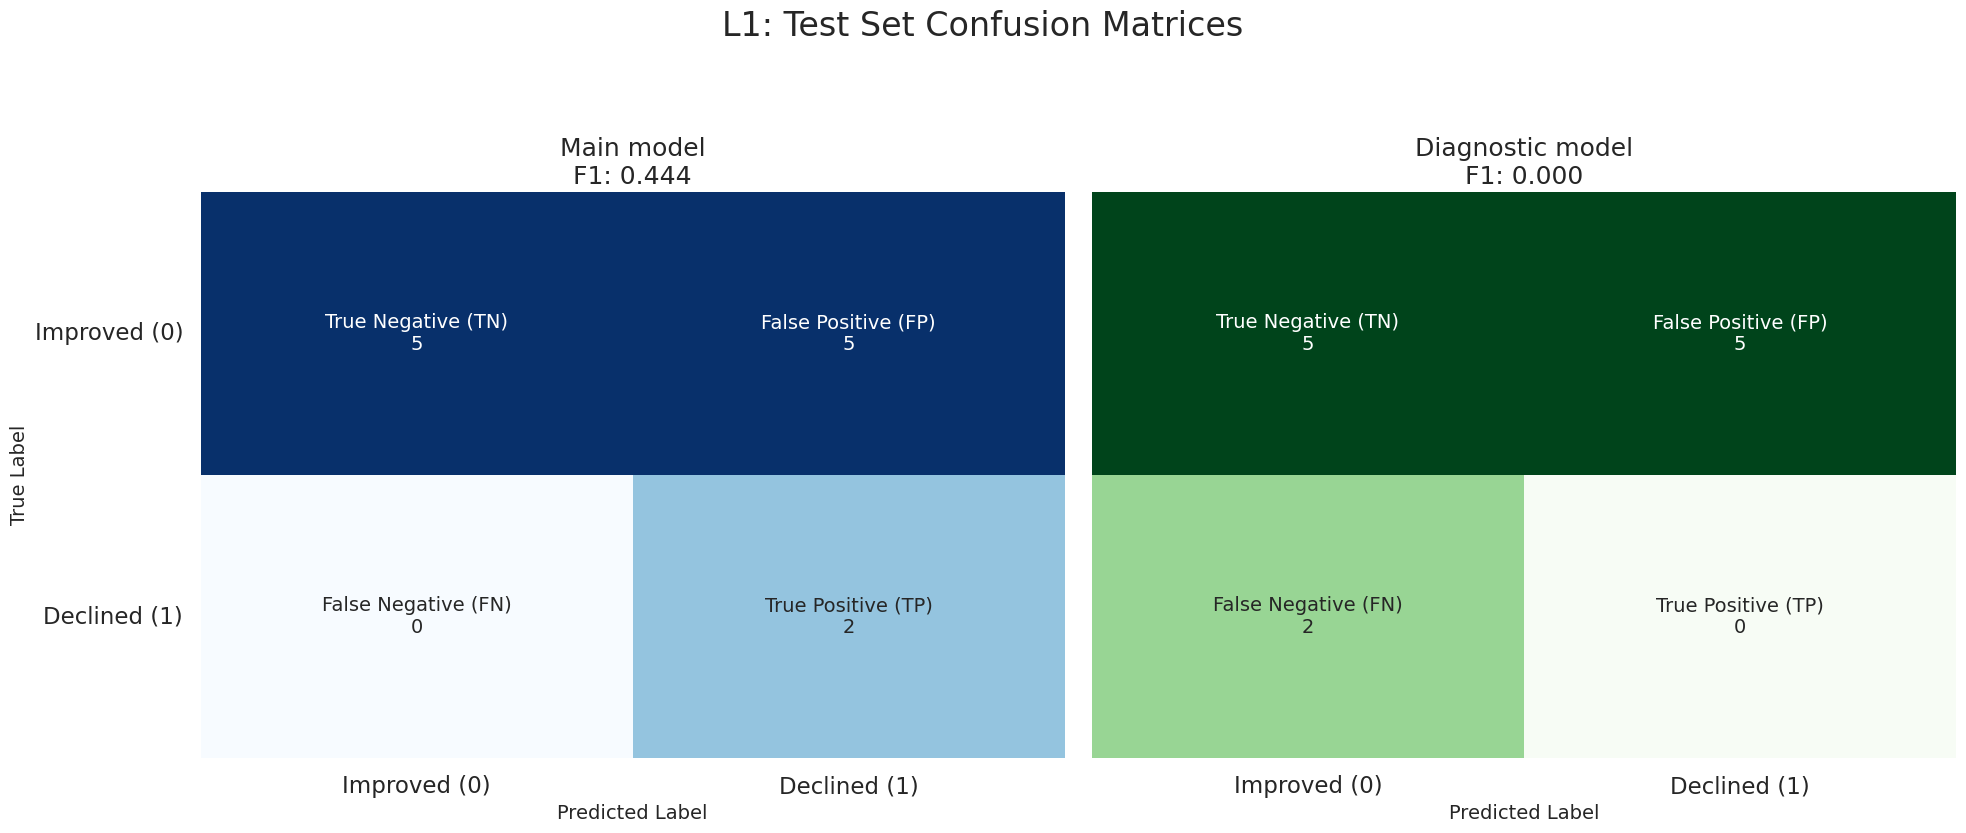

  Saved plots_l1_main_v7_diag_v26_confusion_matrices_l1.png

[PLOT-l1] Test metric comparison (main vs diagnostic)...


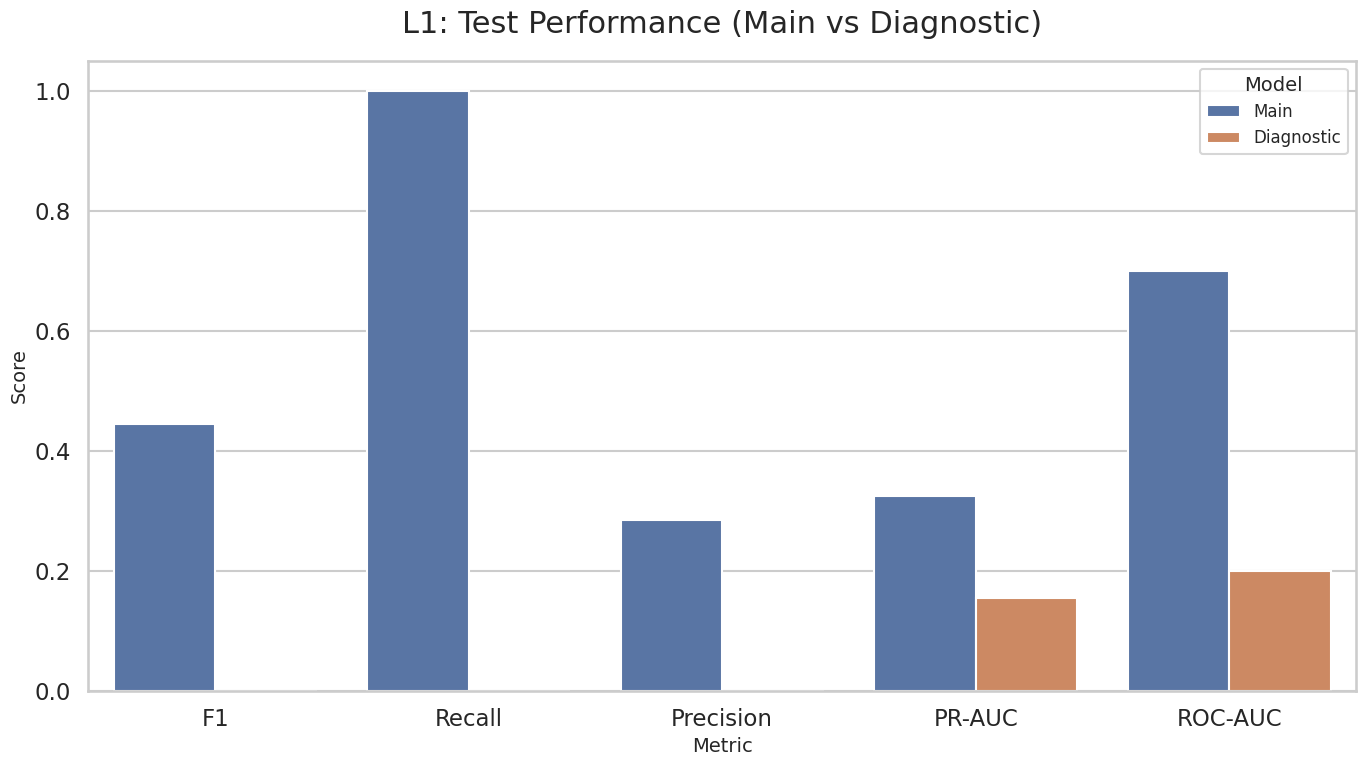

  Saved plots_l1_main_v7_diag_v26_metrics_main_vs_diag_l1.png

[PLOT-l1] Probability distribution on TEST...


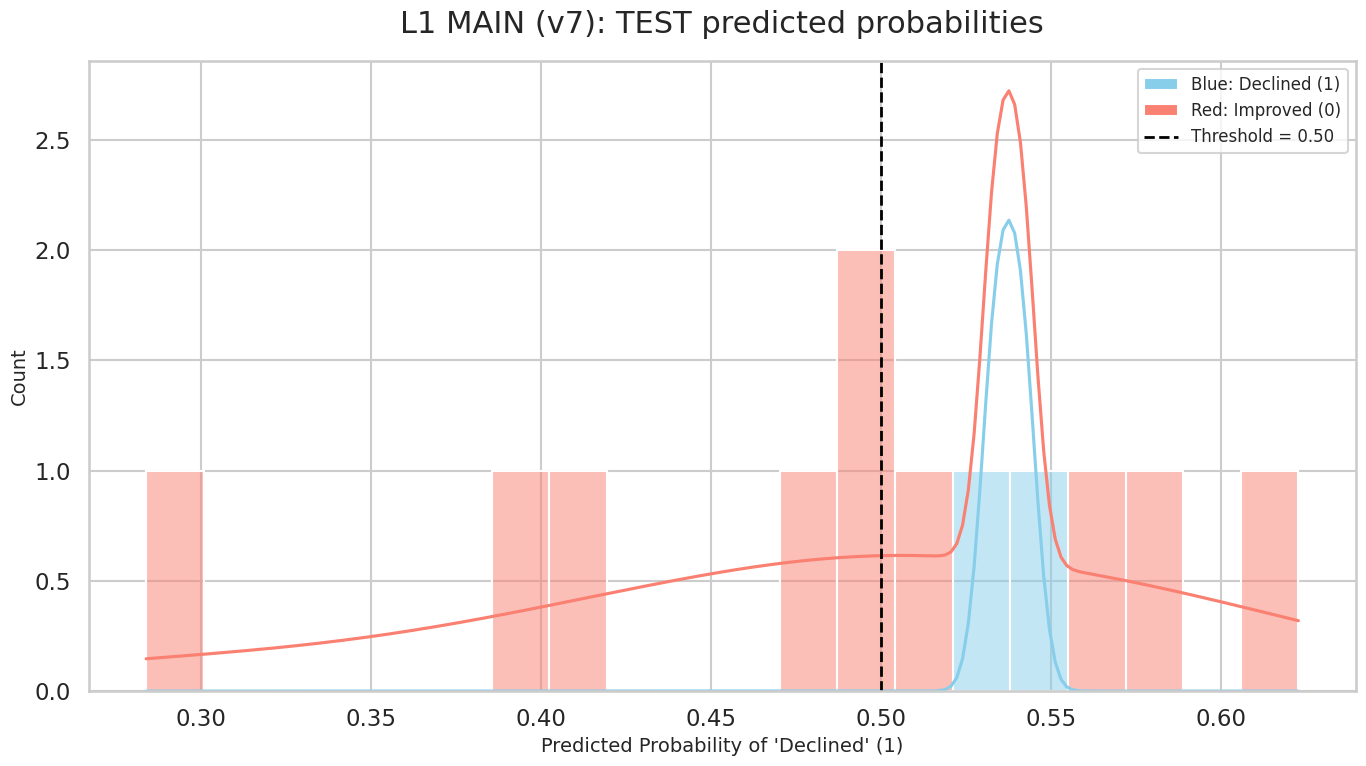

  Saved plots_l1_main_v7_diag_v26_probability_distribution_l1.png

[PLOT-l1_diag] Probability distribution on TEST...


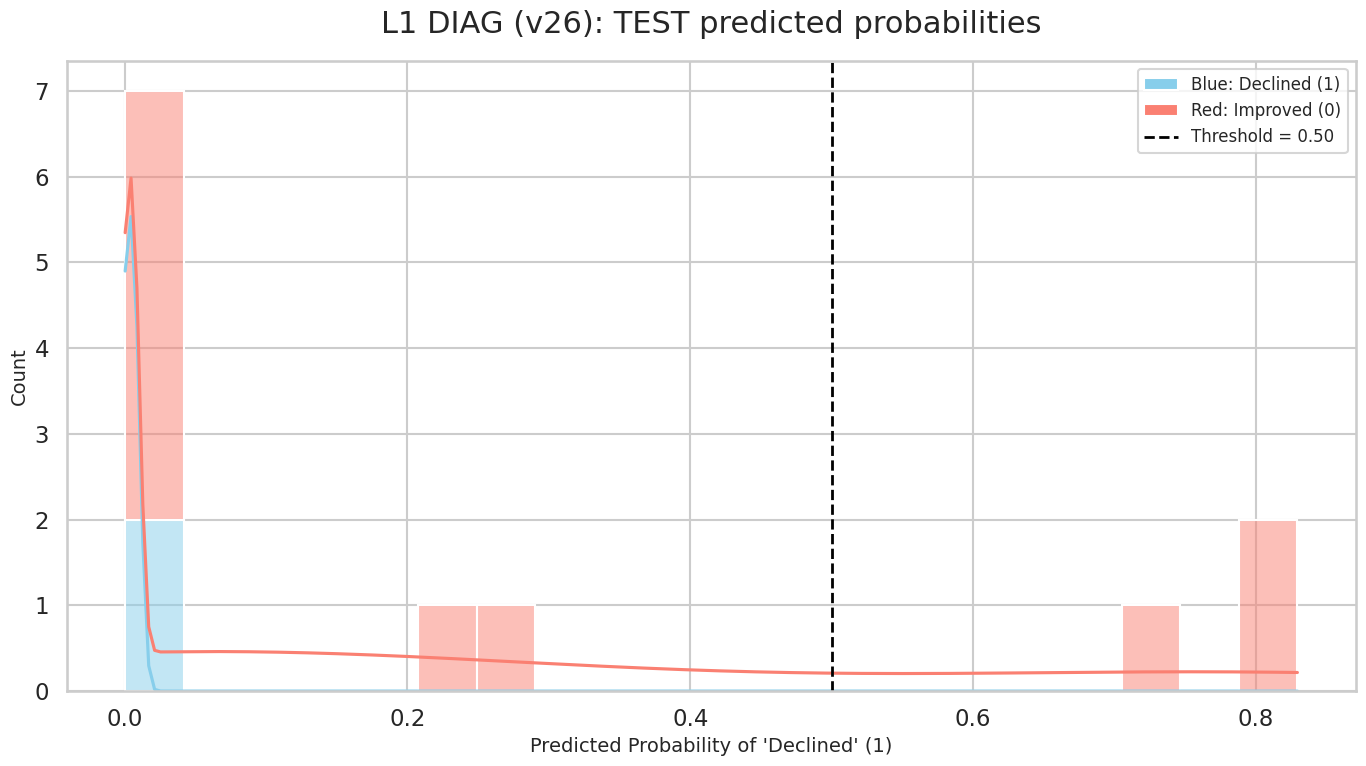

  Saved plots_l1_main_v7_diag_v26_probability_distribution_l1_diag.png

[PLOT-l1] L1 coefficients and odds ratios...


/tmp/ipython-input-134706458.py:369: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="coef", y="feature", palette="vlag")


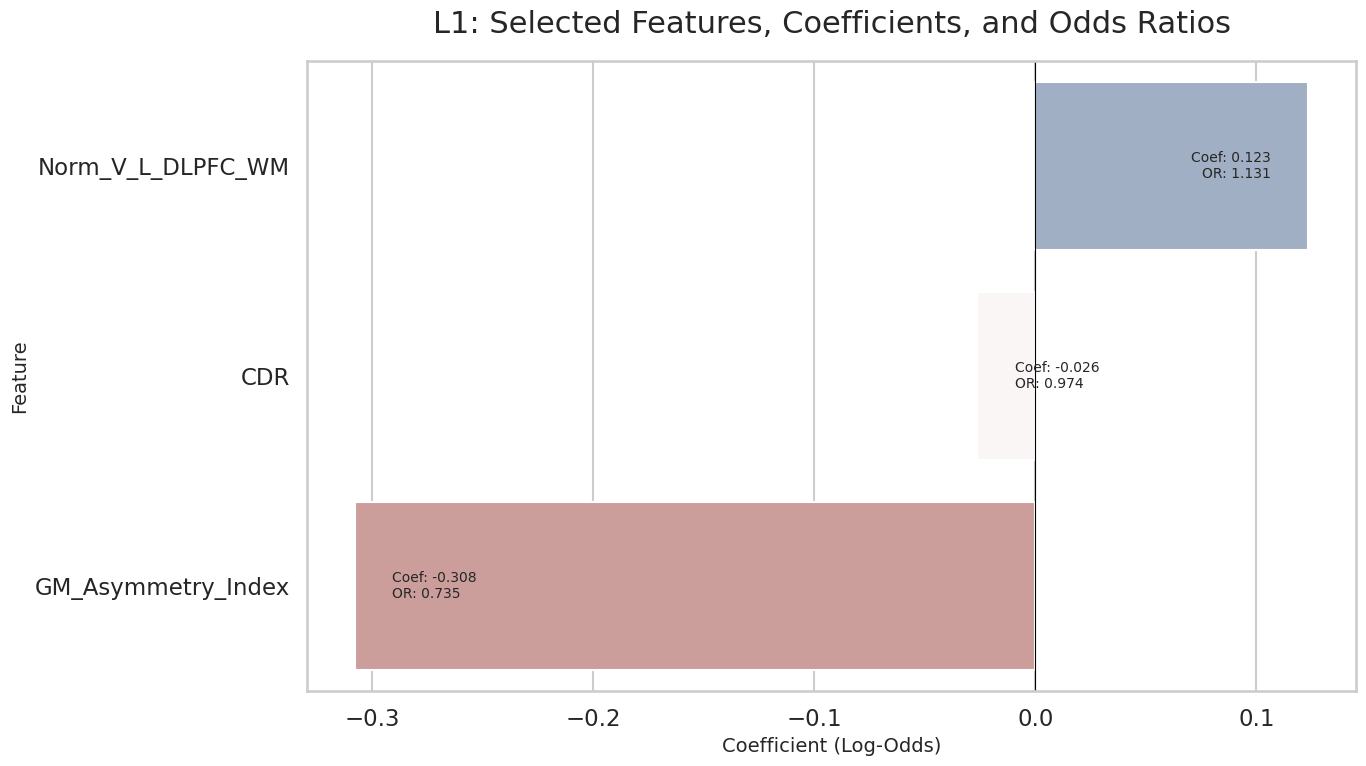

  Saved plots_l1_main_v7_diag_v26_l1_coeffs_odds_l1.png

[PLOT-l1] Coefficient comparison: L1 vs diagnostic...


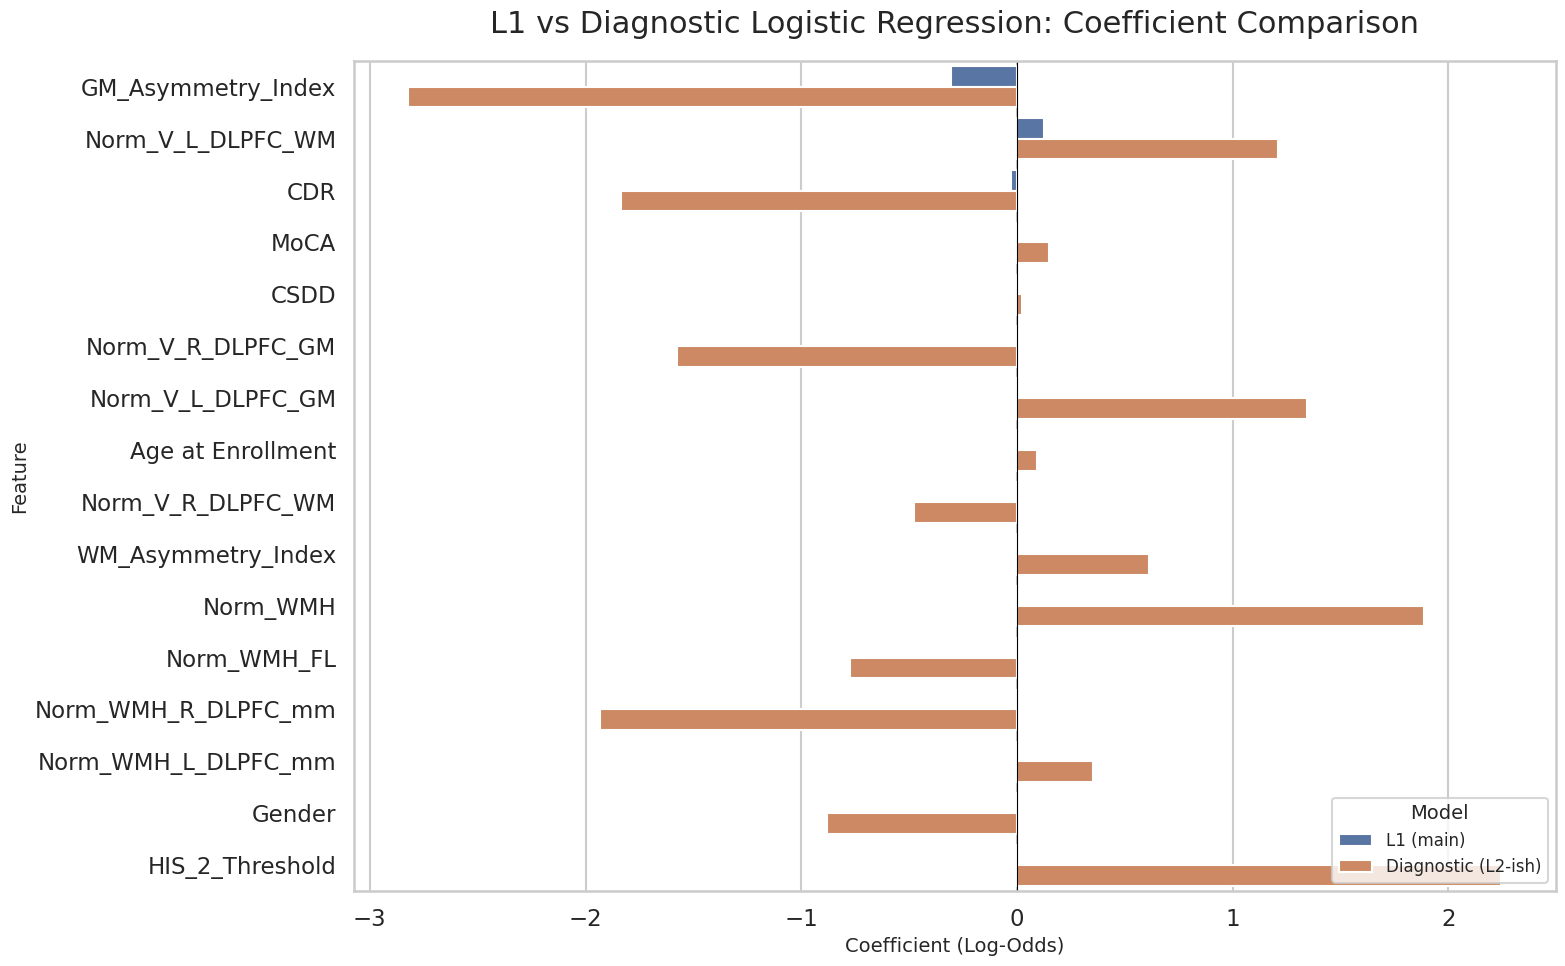

  Saved plots_l1_main_v7_diag_v26_l1_vs_diag_coeffs_l1.png

[PLOT-l1] Permutation importance (L1 main model (v7))...
  This may take some time...


/tmp/ipython-input-134706458.py:484: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


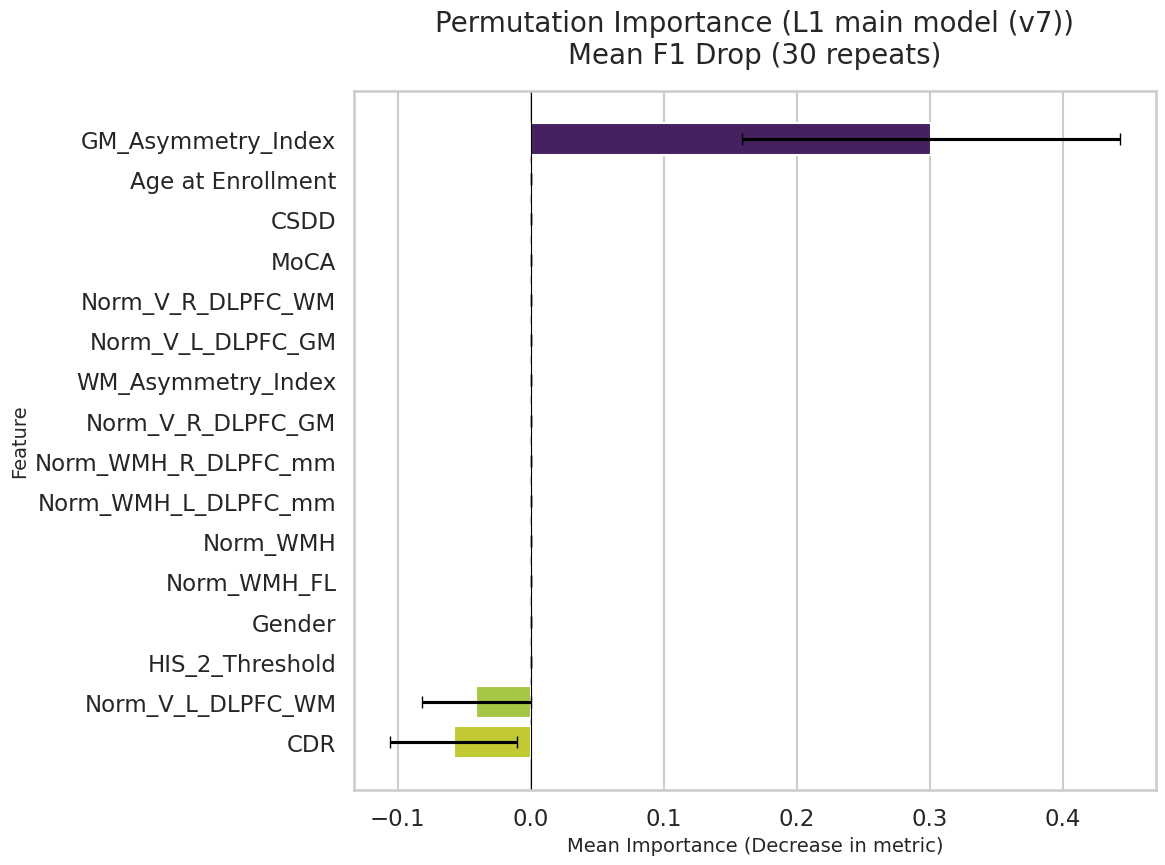

  Top 5 permutation importances:
           feature  importance_mean  importance_std
GM_Asymmetry_Index         0.300794        0.142081
 Age at Enrollment         0.000000        0.000000
              CSDD         0.000000        0.000000
              MoCA         0.000000        0.000000
 Norm_V_R_DLPFC_WM         0.000000        0.000000
  Saved plots_l1_main_v7_diag_v26_perm_importance_l1.png

[PLOT-l1] SHAP LinearExplainer (L1)...
  SHAP summary plot...


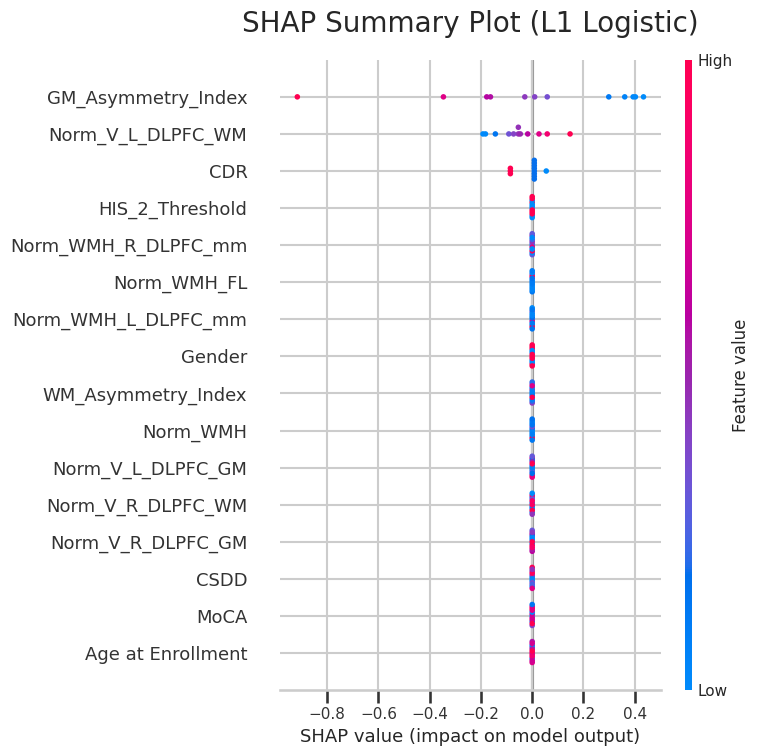

  Saved plots_l1_main_v7_diag_v26_shap_summary_l1.png
  SHAP force plot for sample 0...
  Force plot saved to plots_l1_main_v7_diag_v26_shap_force_sample0_l1.html
  SHAP dependence plots for top 3 |coef| features...


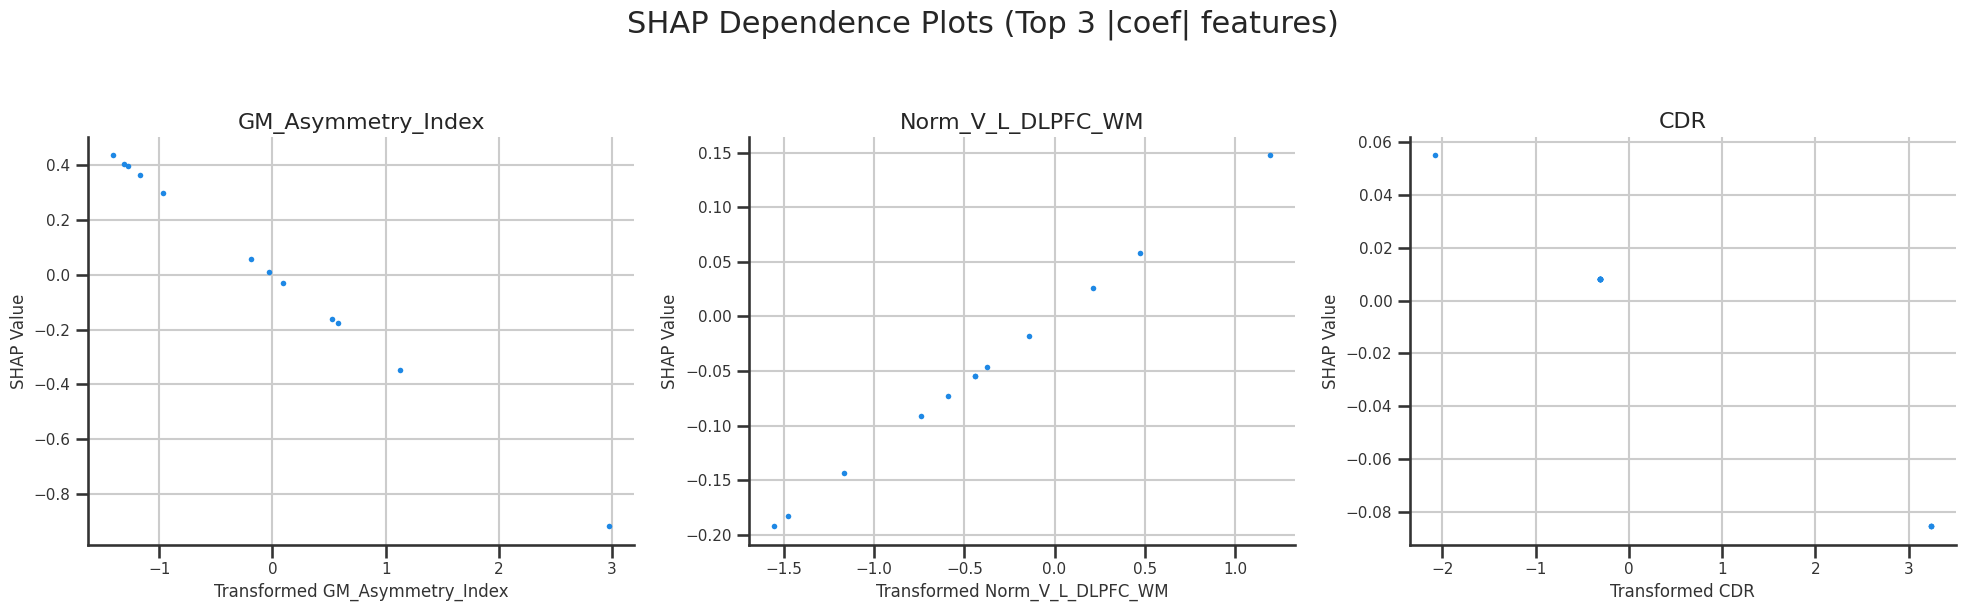

  Saved plots_l1_main_v7_diag_v26_shap_dependence_l1.png


In [ ]:
"""
Generic Plotting and Interpretation for L1, RF, XGB
===================================================

Works with artifacts saved by the "generic_soft" pipeline:
    ROOT_MODEL_DIR/<model_tag>/...

Models:
    model_tag = "l1", "rf", "xgb"

Per-model folder contains:
    final_pipe_<tag>.pkl          : main tuned pipeline
    diag_pipe_<tag>.pkl           : diagnostic pipeline
    test_metrics_<tag>.pkl        : dict with metrics (f1, recall, precision, pr_auc, roc_auc, confusion_matrix)
    diag_metrics_<tag>.pkl
    feature_effects_<tag>.pkl     : L1: coef+odds; RF/XGB: importances
    diag_feature_effects_<tag>.pkl
    train_test_data_<tag>.pkl     : (X_train, X_test, y_train, y_test)
    feature_names_<tag>.pkl       : original feature names
    random_state_<tag>.pkl        : RND int

This script:

- Loads artifacts using a generic loader.
- Provides generic plots:
    * Confusion matrices (main vs diagnostic)
    * Test metric comparison barplots (main vs diagnostic, or across models)
    * Probability distributions of predicted probabilities
- Provides L1-specific:
    * Coefficient barplots with odds ratios
    * L1 vs diagnostic coefficient comparison
    * Permutation importance (F1 drop)
    * SHAP LinearExplainer summary and dependence plots
- Provides tree-specific (RF/XGB):
    * Feature importance comparison across RF/XGB
    * Permutation importance
    * SHAP TreeExplainer summary, force, and dependence plots

Use:
    - Call run_plots_for_model("l1")
    - Call run_plots_for_model("rf")
    - Call run_plots_for_model("xgb")
    - Call run_combined_tree_plots() for RF+XGB comparison
"""

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
import shap

ROOT_MODEL_DIR = "model_params_generic_soft"

import re

def get_model_version_dir(model_tag: str, version: int = None) -> str:
    """
    Return the directory for a given model_tag and version.

    Folder names can be:
        version_18
        version_18_l1
        version_18_something_else
    This function:
        - extracts the number immediately after 'version_'
        - ignores anything after that
    If version is None, use the highest existing version_<N*> under ROOT_MODEL_DIR/model_tag.
    """
    base_dir = os.path.join(ROOT_MODEL_DIR, model_tag)

    if not os.path.exists(base_dir):
        raise FileNotFoundError(f"No directory found for model_tag={model_tag} at {base_dir}")

    # Helper to extract version number from folder name
    def extract_version_num(name: str):
        # match 'version_' followed by digits
        m = re.match(r"version_(\d+)", name)
        if m:
            return int(m.group(1))
        return None

    # Collect (version_num, folder_name)
    candidates = []
    for name in os.listdir(base_dir):
        v = extract_version_num(name)
        if v is not None and os.path.isdir(os.path.join(base_dir, name)):
            candidates.append((v, name))

    if not candidates:
        raise FileNotFoundError(f"No version_* subfolders found in {base_dir}")

    if version is None:
        # pick highest version number
        best_v = max(v for v, _ in candidates)
    else:
        best_v = version

    # find the folder that has this version number (first match)
    for v, name in candidates:
        if v == best_v:
            version_dir = os.path.join(base_dir, name)
            print(f"[LOAD-{model_tag}] Using version {v}: {version_dir}")
            return version_dir

    raise FileNotFoundError(f"No folder with version_{best_v}* found in {base_dir}")


sns.set_theme(style="whitegrid", context="talk")


# =============================================================================
# 1. LOADING ARTIFACTS
# =============================================================================

def load_model_artifacts(model_tag: str, version: int = None):
    model_dir = get_model_version_dir(model_tag, version)
    print(f"\n[LOAD-{model_tag}] Loading artifacts from {model_dir}...")

    v_str = os.path.basename(model_dir).split("_")[1]  # '18' from 'version_18_*'

    final_pipe = joblib.load(os.path.join(model_dir, f"final_pipe_{model_tag}_v{v_str}.pkl"))
    diag_pipe = joblib.load(os.path.join(model_dir, f"diag_pipe_{model_tag}_v{v_str}.pkl"))
    test_metrics = joblib.load(os.path.join(model_dir, f"test_metrics_{model_tag}_v{v_str}.pkl"))
    diag_metrics = joblib.load(os.path.join(model_dir, f"diag_metrics_{model_tag}_v{v_str}.pkl"))
    feat_main = joblib.load(os.path.join(model_dir, f"feature_effects_{model_tag}_v{v_str}.pkl"))
    feat_diag = joblib.load(os.path.join(model_dir, f"diag_feature_effects_{model_tag}_v{v_str}.pkl"))
    X_train, X_test, y_train, y_test = joblib.load(
        os.path.join(model_dir, f"train_test_data_{model_tag}_v{v_str}.pkl")
    )
    feature_names = joblib.load(os.path.join(model_dir, f"feature_names_{model_tag}_v{v_str}.pkl"))
    rnd = joblib.load(os.path.join(model_dir, f"random_state_{model_tag}_v{v_str}.pkl"))

    print(f"  ✓ Loaded final_pipe_{model_tag}")
    print(f"  ✓ Loaded diag_pipe_{model_tag}")
    print(f"  ✓ Loaded test_metrics_{model_tag}")
    print(f"  ✓ Loaded diag_metrics_{model_tag}")
    print(f"  ✓ Loaded feature_effects_{model_tag}")
    print(f"  ✓ Loaded diag_feature_effects_{model_tag}")
    print(f"  ✓ Loaded train/test data for {model_tag}")
    print(f"  ✓ Loaded feature names and random_state_{model_tag}")
    print(f"[LOAD-{model_tag}] All artifacts loaded successfully.\n")

    return (final_pipe, diag_pipe,
            test_metrics, diag_metrics,
            feat_main, feat_diag,
            X_train, X_test, y_train, y_test,
            feature_names, rnd)


def load_main_and_diag_from_versions(model_tag: str,
                                     main_version: int,
                                     diag_version: int):
    """
    Load MAIN artifacts from main_version and DIAG artifacts from diag_version
    for the same model_tag ('l1','rf','xgb').

    MAIN (from main_version):
        - final_pipe, test_metrics, feature_effects, train_test_data,
          feature_names, random_state

    DIAG (from diag_version):
        - diag_pipe, diag_metrics, diag_feature_effects
    """
    # MAIN
    main_dir = get_model_version_dir(model_tag, main_version)
    v_main = os.path.basename(main_dir).split("_")[1]  # numeric part after 'version_'

    final_pipe = joblib.load(os.path.join(main_dir, f"final_pipe_{model_tag}_v{v_main}.pkl"))
    test_metrics = joblib.load(os.path.join(main_dir, f"test_metrics_{model_tag}_v{v_main}.pkl"))
    feat_main = joblib.load(os.path.join(main_dir, f"feature_effects_{model_tag}_v{v_main}.pkl"))
    X_train, X_test, y_train, y_test = joblib.load(
        os.path.join(main_dir, f"train_test_data_{model_tag}_v{v_main}.pkl")
    )
    feature_names = joblib.load(os.path.join(main_dir, f"feature_names_{model_tag}_v{v_main}.pkl"))
    rnd = joblib.load(os.path.join(main_dir, f"random_state_{model_tag}_v{v_main}.pkl"))

    # DIAG
    diag_dir = get_model_version_dir(model_tag, diag_version)
    v_diag = os.path.basename(diag_dir).split("_")[1]

    diag_pipe = joblib.load(os.path.join(diag_dir, f"diag_pipe_{model_tag}_v{v_diag}.pkl"))
    diag_metrics = joblib.load(os.path.join(diag_dir, f"diag_metrics_{model_tag}_v{v_diag}.pkl"))
    feat_diag = joblib.load(os.path.join(diag_dir, f"diag_feature_effects_{model_tag}_v{v_diag}.pkl"))

    print(f"\n[LOAD-{model_tag}] MAIN v{v_main} from {main_dir}")
    print(f"[LOAD-{model_tag}] DIAG v{v_diag} from {diag_dir}")

    return (final_pipe, diag_pipe,
            test_metrics, diag_metrics,
            feat_main, feat_diag,
            X_train, X_test, y_train, y_test,
            feature_names, rnd)


# =============================================================================
# 2. GENERIC PLOTS (MAIN vs DIAG FOR ONE MODEL)
# =============================================================================

def plot_confusion_matrices(model_tag: str, test_metrics, diag_metrics, fname_prefix: str):
    """
    Plot two confusion matrix heatmaps: main vs diagnostic.
    """
    print(f"\n[PLOT-{model_tag}] Confusion matrices (main vs diagnostic)...")

    cm_main = test_metrics["confusion_matrix"]
    cm_diag = diag_metrics["confusion_matrix"]

    cm_labels = ["Improved (0)", "Declined (1)"]
    cm_quadrant_labels = [
        ["True Negative (TN)", "False Positive (FP)"],
        ["False Negative (FN)", "True Positive (TP)"],
    ]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    fig.suptitle(f"{model_tag.upper()}: Test Set Confusion Matrices", fontsize=24, y=1.05)

    # main
    labels_main = np.asarray([
        f"{cm_quadrant_labels[0][0]}\n{cm_main[0,0]}",
        f"{cm_quadrant_labels[0][1]}\n{cm_main[0,1]}",
        f"{cm_quadrant_labels[1][0]}\n{cm_main[1,0]}",
        f"{cm_quadrant_labels[1][1]}\n{cm_main[1,1]}"
    ]).reshape(2, 2)
    sns.heatmap(
        cm_main,
        annot=labels_main,
        fmt="",
        cmap="Blues",
        cbar=False,
        ax=axes[0],
        annot_kws={"size": 14},
    )
    axes[0].set_title(f"Main model\nF1: {test_metrics['f1']:.3f}", fontsize=18)
    axes[0].set_xlabel("Predicted Label", fontsize=14)
    axes[0].set_ylabel("True Label", fontsize=14)
    axes[0].set_xticklabels(cm_labels)
    axes[0].set_yticklabels(cm_labels, rotation=0)

    # diag
    labels_diag = np.asarray([
        f"{cm_quadrant_labels[0][0]}\n{cm_diag[0,0]}",
        f"{cm_quadrant_labels[0][1]}\n{cm_diag[0,1]}",
        f"{cm_quadrant_labels[1][0]}\n{cm_diag[1,0]}",
        f"{cm_quadrant_labels[1][1]}\n{cm_diag[1,1]}"
    ]).reshape(2, 2)
    sns.heatmap(
        cm_diag,
        annot=labels_diag,
        fmt="",
        cmap="Greens",
        cbar=False,
        ax=axes[1],
        annot_kws={"size": 14},
    )
    axes[1].set_title(f"Diagnostic model\nF1: {diag_metrics['f1']:.3f}", fontsize=18)
    axes[1].set_xlabel("Predicted Label", fontsize=14)
    axes[1].set_xticklabels(cm_labels)
    axes[1].set_yticklabels(cm_labels, rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 1])
    fname = f"{fname_prefix}_confusion_matrices_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_metric_comparison(model_tag: str, test_metrics, diag_metrics, fname_prefix: str, title_suffix: str = ""):
    """
    Barplot comparing F1, Recall, Precision, PR-AUC, ROC-AUC between main and diag models.
    """
    print(f"\n[PLOT-{model_tag}] Test metric comparison (main vs diagnostic)...")

    metrics_data = {
        "Model": ["Main", "Main", "Main", "Main", "Main",
                  "Diagnostic", "Diagnostic", "Diagnostic", "Diagnostic", "Diagnostic"],
        "Metric": ["F1", "Recall", "Precision", "PR-AUC", "ROC-AUC"] * 2,
        "Score": [
            float(test_metrics["f1"]),
            float(test_metrics["recall"]),
            float(test_metrics["precision"]),
            float(test_metrics["pr_auc"]),
            float(test_metrics["roc_auc"]),
            float(diag_metrics["f1"]),
            float(diag_metrics["recall"]),
            float(diag_metrics["precision"]),
            float(diag_metrics["pr_auc"]),
            float(diag_metrics["roc_auc"]),
        ],
    }
    df = pd.DataFrame(metrics_data)

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(data=df, x="Metric", y="Score", hue="Model", palette="deep")
    ax.set_title(f"{model_tag.upper()}: Test Performance (Main vs Diagnostic){title_suffix}", fontsize=22, pad=20)
    ax.set_xlabel("Metric", fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.legend(title="Model", fontsize=12, title_fontsize=14, loc="upper right")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    fname = f"{fname_prefix}_metrics_main_vs_diag_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_probability_distribution(model_tag: str, pipe, X_test, y_test, threshold: float, fname_prefix: str, title: str):
    """
    Histogram of predicted probabilities, colored by true label.
    """
    print(f"\n[PLOT-{model_tag}] Probability distribution on TEST...")

    y_prob = pipe.predict_proba(X_test)[:, 1]
    df = pd.DataFrame({
        "Probability": y_prob,
        "Actual Outcome": y_test.map({0: "Improved (0)", 1: "Declined (1)"})
    })

    plt.figure(figsize=(14, 8))
    ax = sns.histplot(
        data=df,
        x="Probability",
        hue="Actual Outcome",
        multiple="stack",
        kde=True,
        bins=20,
        palette={"Improved (0)": "salmon", "Declined (1)": "skyblue"},
        legend=False
    )
    ax.set_title(title, fontsize=22, pad=20)
    ax.set_xlabel("Predicted Probability of 'Declined' (1)", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=2, label=f"Threshold={threshold:.2f}")

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor="skyblue", label="Blue: Declined (1)"),
        Patch(facecolor="salmon", label="Red: Improved (0)"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=f"Threshold = {threshold:.2f}")
    ]
    ax.legend(handles=legend_elements, fontsize=12, title_fontsize=14, loc="best")

    plt.tight_layout()
    fname = f"{fname_prefix}_probability_distribution_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


# =============================================================================
# 3. L1-SPECIFIC PLOTS
# =============================================================================

def plot_l1_coefficients(model_tag: str, coef_df: pd.DataFrame, fname_prefix: str):
    """
    Barplot of non-zero L1 coefficients with odds ratios.
    Expects columns: 'feature', 'coef', 'odds_ratio'.
    """
    print(f"\n[PLOT-{model_tag}] L1 coefficients and odds ratios...")

    df = coef_df.copy()
    df = df[df["coef"] != 0].sort_values(by="coef", ascending=False)

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(data=df, x="coef", y="feature", palette="vlag")
    ax.set_title(f"{model_tag.upper()}: Selected Features, Coefficients, and Odds Ratios", fontsize=22, pad=20)
    ax.set_xlabel("Coefficient (Log-Odds)", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.axvline(0, color="black", linewidth=0.8)

    for p in ax.patches:
        coef_val = p.get_width()
        odds_ratio = np.exp(coef_val)
        label_text = f"Coef: {coef_val:.3f}\nOR: {odds_ratio:.3f}"
        x_pos = coef_val - 0.02 if coef_val > 0 else coef_val + 0.02
        ha = "right" if coef_val > 0 else "left"
        ax.annotate(
            label_text,
            (x_pos, p.get_y() + p.get_height() / 2),
            ha=ha,
            va="center",
            fontsize=10,
            xytext=(5 if coef_val > 0 else -5, 0),
            textcoords="offset points"
        )

    plt.tight_layout()
    fname = f"{fname_prefix}_l1_coeffs_odds_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_l1_vs_diag_coeffs(model_tag: str, coef_main: pd.DataFrame, diag_pipe, fname_prefix: str):
    """
    Compare L1 vs diagnostic coefficients on same features.

    coef_main: DataFrame from feature_effects_<model_tag>.pkl
               columns at least: ['feature', 'coef']
    """
    print(f"\n[PLOT-{model_tag}] Coefficient comparison: L1 vs diagnostic...")

    # Diagnostic coefficients
    feature_names_diag = diag_pipe.named_steps["prep"].get_feature_names_out().tolist()
    coefs_diag = diag_pipe.named_steps["clf"].coef_.ravel()
    diag_coef_df = pd.DataFrame({
        "feature": feature_names_diag,
        "coef_diag": coefs_diag
    })

    coef_main = coef_main.copy()
    coef_main["coef_main"] = coef_main["coef"]

    comp_df = pd.merge(
        coef_main[["feature", "coef_main"]],
        diag_coef_df,
        on="feature",
        how="inner"
    )

    comp_melt = comp_df.melt(id_vars="feature", var_name="Model", value_name="Coefficient")
    comp_melt["Model"] = comp_melt["Model"].map({
        "coef_main": "L1 (main)",
        "coef_diag": "Diagnostic (L2-ish)"
    })

    plt.figure(figsize=(16, 10))
    ax = sns.barplot(
        data=comp_melt,
        x="Coefficient",
        y="feature",
        hue="Model",
        palette="deep"
    )
    ax.set_title("L1 vs Diagnostic Logistic Regression: Coefficient Comparison", fontsize=22, pad=20)
    ax.set_xlabel("Coefficient (Log-Odds)", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.legend(title="Model", fontsize=12, title_fontsize=14, loc="lower right")

    plt.tight_layout()
    fname = f"{fname_prefix}_l1_vs_diag_coeffs_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


def plot_permutation_importance_model(
    model_tag: str,
    pipe,
    X_test,
    y_test,
    rnd: int,
    scoring: str,
    fname_prefix: str,
    title: str
):
    """
    Permutation importance on TEST for a given pipeline.
    """
    print(f"\n[PLOT-{model_tag}] Permutation importance ({title})...")
    print("  This may take some time...")

    perm = permutation_importance(
        pipe,
        X_test,
        y_test,
        n_repeats=30,
        random_state=rnd,
        scoring=scoring
    )

    df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values(by="importance_mean", ascending=False)

    plt.figure(figsize=(12, 9))
    ax = sns.barplot(
        data=df,
        x="importance_mean",
        y="feature",
        palette="viridis"
    )
    ax.errorbar(
        x=df["importance_mean"],
        y=df["feature"],
        xerr=df["importance_std"],
        fmt="none",
        c="black",
        capsize=4
    )
    ax.set_title(f"Permutation Importance ({title})\nMean {scoring.upper()} Drop (30 repeats)", fontsize=20, pad=20)
    ax.set_xlabel("Mean Importance (Decrease in metric)", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    fname = f"{fname_prefix}_perm_importance_{model_tag}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print("  Top 5 permutation importances:")
    print(df.head(5).to_string(index=False))
    print(f"  Saved {fname}")


def plot_l1_shap(
    model_tag: str,
    final_pipe,
    X_train,
    X_test,
    fname_prefix: str
):
    """
    SHAP LinearExplainer for L1 logistic.

    - Summary plot
    - Force plot for a single example
    - Dependence plots for top 3 permutation-importance features
      (here we approximate top 3 using coefficient magnitude).
    """
    print(f"\n[PLOT-{model_tag}] SHAP LinearExplainer (L1)...")
    preprocessor = final_pipe.named_steps["prep"]
    classifier = final_pipe.named_steps["clf"]
    feature_names = preprocessor.get_feature_names_out()

    X_train_t = preprocessor.transform(X_train)
    X_test_t = preprocessor.transform(X_test)
    X_train_df = pd.DataFrame(X_train_t, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_t, columns=feature_names)

    explainer = shap.LinearExplainer(classifier, X_train_df)
    shap_values = explainer(X_test_df)

    # Summary plot
    print("  SHAP summary plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_df, plot_type="dot", show=False)
    plt.title("SHAP Summary Plot (L1 Logistic)", fontsize=20, pad=20)
    plt.tight_layout()
    fname_sum = f"{fname_prefix}_shap_summary_{model_tag}.png"
    plt.savefig(fname_sum, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_sum}")

    # Force plot for one sample
    print("  SHAP force plot for sample 0...")
    sample_index = 0
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[0]

    force_plot = shap.force_plot(
        base_value=base_value,
        shap_values=shap_values.values[sample_index, :],
        features=X_test_df.iloc[sample_index, :],
        feature_names=feature_names,
        matplotlib=False,
        show=False
    )
    html_fname = f"{fname_prefix}_shap_force_sample0_{model_tag}.html"
    shap.save_html(html_fname, force_plot)
    print(f"  Force plot saved to {html_fname}")

    # Dependence plots for top 3 |coef|
    # Use abs(coef) from classifier.coef_
    coefs = classifier.coef_.ravel()
    top_idx = np.argsort(np.abs(coefs))[::-1][:3]
    top_features = [feature_names[i] for i in top_idx]

    print("  SHAP dependence plots for top 3 |coef| features...")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("SHAP Dependence Plots (Top 3 |coef| features)", fontsize=22, y=1.03)
    for i, feat in enumerate(top_features):
        shap.dependence_plot(
            ind=feat,
            shap_values=shap_values.values,
            features=X_test_df,
            feature_names=feature_names,
            ax=axes[i],
            show=False,
            interaction_index=None
        )
        axes[i].set_title(feat, fontsize=16)
        axes[i].set_ylabel("SHAP Value", fontsize=12)
        axes[i].set_xlabel(f"Transformed {feat}", fontsize=12)

    plt.tight_layout()
    fname_dep = f"{fname_prefix}_shap_dependence_{model_tag}.png"
    plt.savefig(fname_dep, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_dep}")


# =============================================================================
# 4. TREE-SPECIFIC PLOTS AND COMBINED RF+XGB
# =============================================================================

def tree_shap_analysis(
    model_tag: str,
    diag_pipe,
    X_train, X_test, y_test,
    feature_names,
    fname_prefix: str
):
    """
    SHAP TreeExplainer for a tree-based diagnostic model (RF or XGB).
    """
    print(f"\n[PLOT-{model_tag}] SHAP TreeExplainer (diagnostic tree model)...")

    preprocessor = diag_pipe.named_steps["prep"]
    classifier = diag_pipe.named_steps["clf"]

    X_train_t = preprocessor.transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    try:
        feat_names_t = preprocessor.get_feature_names_out(feature_names)
    except TypeError:
        feat_names_t = preprocessor.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train_t, columns=feat_names_t)
    X_test_df = pd.DataFrame(X_test_t, columns=feat_names_t)

    # TreeExplainer
    explainer = shap.TreeExplainer(classifier, X_train_df)
    print("  Computing SHAP values (this can be slow)...")
    shap_values = explainer(X_test_df)
    print("  SHAP values computed.")

    # Handle different SHAP value formats for RF vs XGB
    # RF returns 3D (2, n_samples, n_features), XGB returns 2D (n_samples, n_features)
    if len(shap_values.values.shape) == 3:
        # RandomForest case - extract class 1
        sv_class1 = shap_values.values[:, :, 1]
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    else:
        # XGBoost case - already represents class 1
        sv_class1 = shap_values.values
        base_value = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[0]

    # Summary plot (class 1)
    print("  SHAP summary plot (class 1)...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        sv_class1,
        X_test_df,
        plot_type="dot",
        show=False
    )
    plt.title(f"SHAP Summary Plot (Diag {model_tag.upper()}, class 1)", fontsize=20, pad=20)
    plt.tight_layout()
    fname_sum = f"{fname_prefix}_shap_summary_diag_{model_tag}.png"
    plt.savefig(fname_sum, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_sum}")

    # Force plot for sample 0
    print("  SHAP force plot for sample 0...")
    sample_index = 0

    fp = shap.force_plot(
        base_value=base_value,
        shap_values=sv_class1[sample_index, :],
        features=X_test_df.iloc[sample_index, :],
        feature_names=feat_names_t,
        matplotlib=False,
        show=False
    )
    html_fname = f"{fname_prefix}_shap_force_sample0_diag_{model_tag}.html"
    shap.save_html(html_fname, fp)
    print(f"  Force plot saved to {html_fname}")

    # Dependence plots: top 3 from permutation importance
    print("  Permutation importance (diagnostic tree) to select top features...")
    perm = permutation_importance(
        diag_pipe,
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        scoring="f1"
    )
    perm_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values(by="importance_mean", ascending=False)
    top_features = perm_df["feature"].head(3).tolist()

    print(f"  Top 3 features (permutation importance): {top_features}")

    fig, axes = plt.subplots(1, len(top_features), figsize=(6 * len(top_features), 6))
    if len(top_features) == 1:
        axes = [axes]
    fig.suptitle(f"SHAP Dependence Plots (Diag {model_tag.upper()}, top perm features)", fontsize=22, y=1.05)

    for i, feat in enumerate(top_features):
        ax = axes[i]
        shap.dependence_plot(
            ind=feat,
            shap_values=sv_class1,
            features=X_test_df,
            feature_names=feat_names_t,
            ax=ax,
            show=False,
            interaction_index="auto"
        )
        ax.set_title(f"{feat}", fontsize=16)
        ax.set_ylabel("SHAP value (impact on class 1)", fontsize=12)
        ax.set_xlabel(f"Transformed {feat}", fontsize=12)

    plt.tight_layout()
    fname_dep = f"{fname_prefix}_shap_dependence_diag_{model_tag}.png"
    plt.savefig(fname_dep, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname_dep}")


def combined_tree_importance_plot(
    feat_rf_main: pd.DataFrame,
    feat_rf_diag: pd.DataFrame,
    feat_xgb_main: pd.DataFrame,
    feat_xgb_diag: pd.DataFrame,
    fname_prefix: str
):
    """
    Combine and compare feature importances across RF/XGB main/diag.

    Assumes:
        feat_rf_main columns: ['feature','importance']
        feat_rf_diag columns: ['feature','importance_diag']
        feat_xgb_main columns: ['feature','importance']
        feat_xgb_diag columns: ['feature','importance_diag']
    """
    print("\n[PLOT-RFXGB] Combined tree feature importance comparison...")

    imp_rf_main = feat_rf_main.rename(columns={"importance": "RF (main)"})
    imp_rf_diag = feat_rf_diag.rename(columns={"importance_diag": "RF (diag)"})
    imp_xgb_main = feat_xgb_main.rename(columns={"importance": "XGB (main)"})
    imp_xgb_diag = feat_xgb_diag.rename(columns={"importance_diag": "XGB (diag)"})

    df = pd.merge(imp_rf_main, imp_rf_diag, on="feature", how="outer")
    df = pd.merge(df, imp_xgb_main, on="feature", how="outer")
    df = pd.merge(df, imp_xgb_diag, on="feature", how="outer")
    df = df.fillna(0)

    df["mean_imp"] = df[["RF (main)", "RF (diag)", "XGB (main)", "XGB (diag)"]].mean(axis=1)
    df = df.sort_values(by="mean_imp", ascending=False).drop(columns="mean_imp")

    df_melt = df.melt(id_vars="feature", var_name="Model", value_name="Importance")

    plt.figure(figsize=(16, 12))
    ax = sns.barplot(
        data=df_melt,
        x="Importance",
        y="feature",
        hue="Model",
        palette="viridis"
    )
    ax.set_title("Tree Models: Feature Importance Comparison (Gini/Gain)", fontsize=24, pad=20)
    ax.set_xlabel("Importance", fontsize=14)
    ax.set_ylabel("Feature", fontsize=14)
    ax.legend(title="Model", fontsize=12, title_fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fname = f"{fname_prefix}_tree_importance_comparison_rf_xgb.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")


# =============================================================================
# 5. TOP-LEVEL WRAPPERS
# =============================================================================

def run_plots_for_model(model_tag: str, version: int = None):
    """
    Run all plots for a single model_tag ('l1','rf','xgb') and optional version.
    If version is None, latest version is used.
    """
    (final_pipe, diag_pipe,
     test_metrics, diag_metrics,
     feat_main, feat_diag,
     X_train, X_test, y_train, y_test,
     feature_names, rnd) = load_model_artifacts(model_tag, version)

    version_dir = get_model_version_dir(model_tag, version)
    version_name = os.path.basename(version_dir)  # e.g. 'version_18_inner_splits=3'
    fname_prefix = f"plots_{model_tag}_{version_name}"

    # Generic plots
    plot_confusion_matrices(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_metric_comparison(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_probability_distribution(
        model_tag,
        final_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} main model: TEST predicted probabilities"
    )
    plot_probability_distribution(
        model_tag + "_diag",
        diag_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} diagnostic model: TEST predicted probabilities"
    )

    # Model-specific
    if model_tag == "l1":
        # feat_main: columns ['feature','coef','odds_ratio',...]
        plot_l1_coefficients(model_tag, feat_main, fname_prefix)
        plot_l1_vs_diag_coeffs(model_tag, feat_main, diag_pipe, fname_prefix)
        plot_permutation_importance_model(
            model_tag,
            final_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title="L1 main model"
        )
        plot_l1_shap(model_tag, final_pipe, X_train, X_test, fname_prefix)

    elif model_tag in ("rf", "xgb"):
        # feat_main: ['feature','importance'], feat_diag: ['feature','importance_diag']
        print(f"[{model_tag}] Tree model: running SHAP for diagnostic pipeline...")
        tree_shap_analysis(
            model_tag,
            diag_pipe,
            X_train, X_test, y_test,
            feature_names,
            fname_prefix=fname_prefix
        )
        plot_permutation_importance_model(
            model_tag + "_diag",
            diag_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title=f"Diagnostic {model_tag.upper()}"
        )
    else:
        print(f"[{model_tag}] No specific extra plots configured.")


def run_plots_for_model_split(model_tag: str,
                              main_version: int,
                              diag_version: int):
    """
    Run all plots for one model_tag, using:
      - main model from main_version
      - diagnostic model from diag_version
    """
    (final_pipe, diag_pipe,
     test_metrics, diag_metrics,
     feat_main, feat_diag,
     X_train, X_test, y_train, y_test,
     feature_names, rnd) = load_main_and_diag_from_versions(
        model_tag, main_version, diag_version
    )

    fname_prefix = f"plots_{model_tag}_main_v{main_version}_diag_v{diag_version}"

    # Generic plots
    plot_confusion_matrices(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_metric_comparison(model_tag, test_metrics, diag_metrics, fname_prefix)
    plot_probability_distribution(
        model_tag,
        final_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} MAIN (v{main_version}): TEST predicted probabilities",
    )
    plot_probability_distribution(
        model_tag + "_diag",
        diag_pipe,
        X_test,
        y_test,
        threshold=0.5,
        fname_prefix=fname_prefix,
        title=f"{model_tag.upper()} DIAG (v{diag_version}): TEST predicted probabilities",
    )

    # Model-specific
    if model_tag == "l1":
        # feat_main: ['feature','coef','odds_ratio',...]
        plot_l1_coefficients(model_tag, feat_main, fname_prefix)
        plot_l1_vs_diag_coeffs(model_tag, feat_main, diag_pipe, fname_prefix)
        plot_permutation_importance_model(
            model_tag,
            final_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title=f"L1 main model (v{main_version})"
        )
        plot_l1_shap(model_tag, final_pipe, X_train, X_test, fname_prefix)

    elif model_tag in ("rf", "xgb"):
        print(f"[{model_tag}] Tree model: running SHAP for DIAG v{diag_version}...")
        tree_shap_analysis(
            model_tag,
            diag_pipe,
            X_train, X_test, y_test,
            feature_names,
            fname_prefix=fname_prefix
        )
        plot_permutation_importance_model(
            model_tag + "_diag",
            diag_pipe,
            X_test,
            y_test,
            rnd,
            scoring="f1",
            fname_prefix=fname_prefix,
            title=f"Diagnostic {model_tag.upper()} (v{diag_version})"
        )
    else:
        print(f"[{model_tag}] No specific extra plots configured.")


def run_combined_tree_plots(l1_version=None, rf_version=None, xgb_version=None):
    """
    Run combined RF+XGB plots:
    - metric comparison across all 6 models (L1 main/diag, RF main/diag, XGB main/diag)
    - tree feature importance comparison (RF/XGB)
    """
    print("\n[COMBINED] Loading L1, RF, XGB for combined plots...")

    # L1
    (_, _, test_l1, diag_l1,
     _, _,
     _, _, _, _, _, _) = load_model_artifacts("l1", l1_version)

    # RF
    (final_rf, diag_rf,
     test_rf, diag_rf_m,
     feat_rf_main, feat_rf_diag,
     X_train_rf, X_test_rf, y_train_rf, y_test_rf,
     feat_names_rf, rnd_rf) = load_model_artifacts("rf", rf_version)

    # XGB
    (final_xgb, diag_xgb,
     test_xgb, diag_xgb_m,
     feat_xgb_main, feat_xgb_diag,
     X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb,
     feat_names_xgb, rnd_xgb) = load_model_artifacts("xgb", xgb_version)

    # Combined metric comparison across all main/diag
    print("\n[COMBINED] Test metric comparison across L1, RF, XGB...")
    metrics_data_all = {
        "Model": [
            "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)",
            "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)",
            "RF (main)", "RF (main)", "RF (main)", "RF (main)", "RF (main)",
            "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)",
            "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)",
            "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)",
        ],
        "Metric": ["F1", "Recall", "Precision", "PR-AUC", "ROC-AUC"] * 6,
        "Score": [
            float(test_l1["f1"]), float(test_l1["recall"]), float(test_l1["precision"]), float(test_l1["pr_auc"]), float(test_l1["roc_auc"]),
            float(diag_l1["f1"]), float(diag_l1["recall"]), float(diag_l1["precision"]), float(diag_l1["pr_auc"]), float(diag_l1["roc_auc"]),
            float(test_rf["f1"]), float(test_rf["recall"]), float(test_rf["precision"]), float(test_rf["pr_auc"]), float(test_rf["roc_auc"]),
            float(diag_rf_m["f1"]), float(diag_rf_m["recall"]), float(diag_rf_m["precision"]), float(diag_rf_m["pr_auc"]), float(diag_rf_m["roc_auc"]),
            float(test_xgb["f1"]), float(test_xgb["recall"]), float(test_xgb["precision"]), float(test_xgb["pr_auc"]), float(test_xgb["roc_auc"]),
            float(diag_xgb_m["f1"]), float(diag_xgb_m["recall"]), float(diag_xgb_m["precision"]), float(diag_xgb_m["pr_auc"]), float(diag_xgb_m["roc_auc"]),
        ]
    }
    df_all = pd.DataFrame(metrics_data_all)
    plt.figure(figsize=(20, 10))
    ax = sns.barplot(
        data=df_all,
        x="Metric",
        y="Score",
        hue="Model",
        palette="tab20"
    )
    ax.set_title("All Models: Test Performance Comparison", fontsize=24, pad=20)
    ax.set_xlabel("Metric", fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.legend(title="Model", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12, title_fontsize=14)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fname = "plots_combined_all_models_metrics.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")

    # Tree importance comparison
    combined_tree_importance_plot(
        feat_rf_main, feat_rf_diag,
        feat_xgb_main, feat_xgb_diag,
        fname_prefix="plots_combined"
    )

def run_combined_tree_plots_split(l1_main_version: int,
                            l1_diag_version: int,
                            rf_main_version: int,
                            rf_diag_version: int,
                            xgb_main_version: int,
                            xgb_diag_version: int):
    """
    Run combined RF+XGB plots + metrics comparison using explicit
    main/diag versions for each model:
      - L1 main/diag
      - RF main/diag
      - XGB main/diag
    """
    print("\n[COMBINED] Loading L1, RF, XGB for combined plots...")

    # L1
    (_, _, test_l1, diag_l1,
     _, _,
     _, _, _, _, _, _) = load_main_and_diag_from_versions(
        "l1", l1_main_version, l1_diag_version
    )

    # RF
    (final_rf, diag_rf,
     test_rf, diag_rf_m,
     feat_rf_main, feat_rf_diag,
     X_train_rf, X_test_rf, y_train_rf, y_test_rf,
     feat_names_rf, rnd_rf) = load_main_and_diag_from_versions(
        "rf", rf_main_version, rf_diag_version
    )

    # XGB
    (final_xgb, diag_xgb,
     test_xgb, diag_xgb_m,
     feat_xgb_main, feat_xgb_diag,
     X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb,
     feat_names_xgb, rnd_xgb) = load_main_and_diag_from_versions(
        "xgb", xgb_main_version, xgb_diag_version
    )

    # Combined metric comparison across all main/diag
    print("\n[COMBINED] Test metric comparison across L1, RF, XGB...")
    metrics_data_all = {
        "Model": [
            "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)", "L1 (main)",
            "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)", "L1 (diag)",
            "RF (main)", "RF (main)", "RF (main)", "RF (main)", "RF (main)",
            "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)", "RF (diag)",
            "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)", "XGB (main)",
            "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)", "XGB (diag)",
        ],
        "Metric": ["F1", "Recall", "Precision", "PR-AUC", "ROC-AUC"] * 6,
        "Score": [
            float(test_l1["f1"]),   float(test_l1["recall"]),   float(test_l1["precision"]),   float(test_l1["pr_auc"]),   float(test_l1["roc_auc"]),
            float(diag_l1["f1"]),   float(diag_l1["recall"]),   float(diag_l1["precision"]),   float(diag_l1["pr_auc"]),   float(diag_l1["roc_auc"]),
            float(test_rf["f1"]),   float(test_rf["recall"]),   float(test_rf["precision"]),   float(test_rf["pr_auc"]),   float(test_rf["roc_auc"]),
            float(diag_rf_m["f1"]), float(diag_rf_m["recall"]), float(diag_rf_m["precision"]), float(diag_rf_m["pr_auc"]), float(diag_rf_m["roc_auc"]),
            float(test_xgb["f1"]),  float(test_xgb["recall"]),  float(test_xgb["precision"]),  float(test_xgb["pr_auc"]),  float(test_xgb["roc_auc"]),
            float(diag_xgb_m["f1"]),float(diag_xgb_m["recall"]),float(diag_xgb_m["precision"]),float(diag_xgb_m["pr_auc"]),float(diag_xgb_m["roc_auc"]),
        ]
    }
    df_all = pd.DataFrame(metrics_data_all)
    plt.figure(figsize=(20, 10))
    ax = sns.barplot(
        data=df_all,
        x="Metric",
        y="Score",
        hue="Model",
        palette="tab20"
    )
    ax.set_title("All Models: Test Performance Comparison", fontsize=24, pad=20)
    ax.set_xlabel("Metric", fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.legend(title="Model", loc="center left", bbox_to_anchor=(1, 0.5),
              fontsize=12, title_fontsize=14)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fname = "plots_combined_all_models_metrics.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fname}")

    # Tree importance comparison (RF/XGB)
    combined_tree_importance_plot(
        feat_rf_main, feat_rf_diag,
        feat_xgb_main, feat_xgb_diag,
        fname_prefix="plots_combined"
    )


# =============================================================================
# 6. MAIN ENTRY POINTS
# =============================================================================

if __name__ == "__main__":
    # Latest versions
    # run_plots_for_model("l1")          # uses latest l1/version_*
    # run_plots_for_model("rf")          # latest rf
    # run_plots_for_model("xgb")         # latest xgb

    # Specific versions
    # run_plots_for_model("l1", version=16)
    # run_plots_for_model("rf", version=5)
    # run_plots_for_model("xgb", version=20)

    # run_combined_tree_plots(l1_version=18, rf_version=5, xgb_version=11)

    # run_combined_tree_plots()



    # # L1, RF, XGB using the same version for main and diag
    # run_plots_for_model("l1", version=16)
    # run_plots_for_model("rf", version=2)
    # run_plots_for_model("xgb", version=11)

    # # Combined metrics/importance using those same versions
    # run_combined_tree_plots(
    #     l1_main_version=16, l1_diag_version=16,
    #     rf_main_version=2,  rf_diag_version=2,
    #     xgb_main_version=11, xgb_diag_version=11
    # )



    # Example choices:
    # L1: main v16, diag v26
    run_plots_for_model_split("l1", main_version=7, diag_version=26)

    # # RF: main v2, diag v6
    # run_plots_for_model_split("rf", main_version=2, diag_version=6)

    # # XGB: main v11 (version_11_k=5), diag v5
    # run_plots_for_model_split("xgb", main_version=11, diag_version=5)


    # # ... optionally call individual splits above ...

    # run_combined_tree_plots_split(
    #     l1_main_version=16, l1_diag_version=26,
    #     rf_main_version=2,  rf_diag_version=6,
    #     xgb_main_version=11, xgb_diag_version=5
    # )



---

## 9. Appendix: Data Scaling Pipeline (Optional)

Alternative preprocessing approach using StandardScaler for numeric features.


## Picking the Best Model

In [ ]:
import os
import re
import joblib
import pandas as pd

ROOT_MODEL_DIR = "model_params_generic_soft"  # already defined in your code


def list_all_versions(model_tag: str):
    """
    Return a sorted list of (version_num, folder_name) for a given model_tag.
    Handles names like 'version_18', 'version_18_inner_splits=3', etc.
    """
    base_dir = os.path.join(ROOT_MODEL_DIR, model_tag)
    if not os.path.exists(base_dir):
        raise FileNotFoundError(f"No directory for model_tag={model_tag} at {base_dir}")

    def extract_version_num(name: str):
        m = re.match(r"version_(\d+)", name)
        if m:
            return int(m.group(1))
        return None

    versions = []
    for name in os.listdir(base_dir):
        path = os.path.join(base_dir, name)
        if not os.path.isdir(path):
            continue
        v = extract_version_num(name)
        if v is not None:
            versions.append((v, name))

    versions.sort(key=lambda x: x[0])  # sort by numeric version
    return versions


def collect_metrics_for_model(model_tag: str) -> pd.DataFrame:
    """
    Loop over all versions for a model_tag ('l1','rf','xgb'),
    load test_metrics and diag_metrics, and return a tidy DataFrame.

    Columns:
        model_tag, version, folder, which ('main' or 'diag'),
        roc_auc, pr_auc, accuracy, f1, precision, recall,
        tn, fp, fn, tp
    """
    rows = []
    versions = list_all_versions(model_tag)

    for v_num, folder_name in versions:
        version_dir = os.path.join(ROOT_MODEL_DIR, model_tag, folder_name)
        v_str = str(v_num)

        # file stems follow your save_artifacts convention: *_v{version}.pkl
        test_path = os.path.join(version_dir, f"test_metrics_{model_tag}_v{v_str}.pkl")
        diag_path = os.path.join(version_dir, f"diag_metrics_{model_tag}_v{v_str}.pkl")

        if not os.path.exists(test_path):
            # skip if somehow test_metrics not saved for this version
            continue

        test_metrics = joblib.load(test_path)
        diag_metrics = joblib.load(diag_path) if os.path.exists(diag_path) else None

        # helper to unpack one metrics dict into a row
        def add_row(which: str, m: dict):
            cm = m.get("confusion_matrix")
            if cm is not None:
                tn, fp, fn, tp = cm.ravel()
            else:
                tn = fp = fn = tp = None

            rows.append({
                "model_tag": model_tag,
                "version": v_num,
                "folder": folder_name,
                "which": which,  # "main" or "diag"
                "roc_auc": float(m.get("roc_auc", float("nan"))),
                "pr_auc": float(m.get("pr_auc", float("nan"))),
                "accuracy": float(m.get("accuracy", float("nan"))),
                "f1": float(m.get("f1", float("nan"))),
                "precision": float(m.get("precision", float("nan"))),
                "recall": float(m.get("recall", float("nan"))),
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
            })

        add_row("main", test_metrics)
        if diag_metrics is not None:
            add_row("diag", diag_metrics)

    df = pd.DataFrame(rows)
    return df


def collect_all_models_metrics() -> pd.DataFrame:
    """
    Collect metrics for all three model types into one DataFrame.
    """
    all_tags = ["l1", "rf", "xgb"]
    dfs = []
    for tag in all_tags:
        try:
            df_tag = collect_metrics_for_model(tag)
            dfs.append(df_tag)
        except FileNotFoundError:
            # model_tag may not exist yet; skip
            continue

    if not dfs:
        return pd.DataFrame()

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all


def sort_metrics_df(df: pd.DataFrame,
                    sort_order=None,
                    ascending=None) -> pd.DataFrame:
    """
    Sort a metrics DataFrame with a configurable order.

    Default:
        recall ↓, f1 ↓, pr_auc ↓, model_tag ↑, which ↑
    """
    if sort_order is None:
        sort_order = ["recall", "f1", "pr_auc", "model_tag", "which"]
    if ascending is None:
        ascending = [False, False, False, True, True]

    # Only keep columns that actually exist in df (in case of per-model df without model_tag)
    cols = [c for c in sort_order if c in df.columns]
    asc = [ascending[sort_order.index(c)] for c in cols]

    return df.sort_values(by=cols, ascending=asc)


# # All models together
# df_metrics = collect_all_models_metrics()
# df_sorted_all = sort_metrics_df(df_metrics)  # or pass custom sort_order/ascending

# print(df_sorted_all[[
#     "model_tag", "version", "which",
#     "roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall",
#     "tn", "fp", "fn", "tp",
#     "folder",
# ]].to_string(index=False))

# Single model (e.g. L1)
df_l1 = collect_metrics_for_model("xgb")
df_l1_sorted = sort_metrics_df(df_l1, ["recall", "pr_auc", "f1"], [False, False, False])

print(df_l1_sorted[[
    "model_tag", "version", "which",
    "roc_auc", "pr_auc", "accuracy", "f1", "precision", "recall",
    "tn", "fp", "fn", "tp",
    "folder",
]].to_string(index=False))


model_tag  version which  roc_auc   pr_auc  accuracy       f1  precision  recall  tn  fp  fn  tp                   folder
      xgb       11  main     0.85 0.500000  0.666667 0.500000   0.333333     1.0   6   4   0   2           version_11_K=5
      xgb       12  main     0.80 0.450000  0.500000 0.400000   0.250000     1.0   4   6   0   2 version_12_k=7_inner_f=5
      xgb        6  main     0.80 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2                version_6
      xgb        8  main     0.80 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2                version_8
      xgb        9  main     0.80 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2      version_9_SMOTE_k=2
      xgb       10  main     0.75 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2     version_10_SMOTE_K=1
      xgb       13  main     0.75 0.416667  0.333333 0.333333   0.200000     1.0   2   8   0   2               version_13
      xgb       14  main

In [ ]:
# import pandas as pd
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline

# # -------------------------------------------------------------------
# # DATA SCALING PIPELINE
# # -------------------------------------------------------------------
# # Assuming 'df_analysis_binary_1_a' is your current dataframe
# df = df_analysis_binary_1_a.copy()

# # 1. Define Columns
# target_col = "w5_change_binary_one_threshold"

# # Binary columns (0/1) - We usually do NOT scale these, just pass them through
# binary_cols = ["Gender", "HIS_2_Threshold"]

# # Feature columns are everything else (excluding target and binaries)
# feature_cols = [c for c in df.columns if c not in [target_col] + binary_cols]

# print(f"Features to Scale ({len(feature_cols)}): {feature_cols}")
# print(f"Features to Passthrough ({len(binary_cols)}): {binary_cols}")

# # 2. Define the Preprocessor
# preproc = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), feature_cols),
#         ("bin", "passthrough", binary_cols),
#     ],
#     remainder="drop", # Drops the target column from X automatically
#     verbose_feature_names_out=False,
# )

# # 3. Create the Pipeline
# pipe = Pipeline([("prep", preproc)])

# # 4. Fit and Transform
# # We drop the target column before passing to the pipeline
# X_scaled_array = pipe.fit_transform(df.drop(columns=[target_col]))

# # 5. Rebuild the DataFrame
# # Get the new column names from the transformer (ensures correct order)
# scaled_feature_names = pipe.named_steps["prep"].get_feature_names_out()

# df_scaled = pd.DataFrame(X_scaled_array, columns=scaled_feature_names, index=df.index)

# # Add the target column back (ensure it's int for classification)
# df_scaled[target_col] = df[target_col].astype(int)

# print("-" * 30)
# print("Scaling Complete. New DataFrame: 'df_scaled'")

Features to Scale (14): ['Age at Enrollment', 'CDR', 'MoCA', 'CSDD', 'Norm_V_R_DLPFC_GM', 'Norm_V_L_DLPFC_GM', 'Norm_V_R_DLPFC_WM', 'Norm_V_L_DLPFC_WM', 'GM_Asymmetry_Index', 'WM_Asymmetry_Index', 'Norm_WMH', 'Norm_WMH_FL', 'Norm_WMH_R_DLPFC_mm', 'Norm_WMH_L_DLPFC_mm']
Features to Passthrough (2): ['Gender', 'HIS_2_Threshold']
------------------------------
Scaling Complete. New DataFrame: 'df_scaled'


In [ ]:
# df_scaled.head(5)

,Age at Enrollment,CDR,MoCA,CSDD,Norm_V_R_DLPFC_GM,Norm_V_L_DLPFC_GM,Norm_V_R_DLPFC_WM,Norm_V_L_DLPFC_WM,GM_Asymmetry_Index,WM_Asymmetry_Index,Norm_WMH,Norm_WMH_FL,Norm_WMH_R_DLPFC_mm,Norm_WMH_L_DLPFC_mm,Gender,HIS_2_Threshold,w5_change_binary_one_threshold
0,-0.148884,2.647999,0.461499,0.411013,0.068271,1.021631,-0.962911,0.357411,0.744503,-0.451694,-0.458336,-0.346573,-0.325539,-0.160615,1.0,0.0,0
1,-0.019999,-0.334213,-0.320018,3.425112,1.157598,-0.015856,-1.284041,-0.099620,-0.914433,-0.557809,0.869785,0.800039,1.234028,-0.113107,1.0,1.0,0
2,1.139963,-0.334213,1.243016,0.959031,-0.786329,0.657551,-0.598165,-1.846827,1.442778,1.627798,-0.473017,-0.435255,-0.325539,-0.179248,1.0,1.0,0
3,0.753309,-0.334213,-0.515397,-0.685022,-1.191166,-0.695212,1.279258,0.330020,0.183841,0.508602,1.206631,0.765836,0.655057,-0.171912,1.0,1.0,0
4,-1.308847,-0.334213,0.070741,-0.137004,-0.582435,-0.585135,-0.643797,-0.601749,-0.545521,-0.334202,-0.107248,-0.098417,-0.263946,-0.098160,0.0,0.0,0
